# EfficientCaps Traffic Sign Recognition

This notebook implements the EfficientCaps model for traffic sign recognition using the GTSRB dataset.

The notebook includes:

- Dataset loading and caching
- Model training and checkpoint saving
- Per-class performance evaluation
- Confusion matrix generation
- Real-world image prediction
- Performance analysis and visualization

The model is trained on GTSRB and evaluated on both benchmark and real-world degraded traffic sign images.

# CELL 1 — INSTALLS, IMPORTS, DRIVE, AND GLOBAL SETTINGS


In [ ]:
# CELL 1 — INSTALLS, IMPORTS, DRIVE, AND GLOBAL SETTINGS


try:
    import datasets
except ImportError:
    !pip -q install datasets

import os, json, time, random, warnings, math, shutil
from pathlib import Path
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
from PIL import Image

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms

from datasets import load_dataset, load_from_disk

warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive already mounted ✓")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Original training constants
NUM_CLASSES    = 43
IMG_SIZE       = 48
BATCH_SIZE     = 128
NUM_EPOCHS     = 30
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
RECON_WEIGHT   = 0.0005
CONF_THRESHOLD = 0.60

# This is False because EfficientCaps architecture is a custom model and does not load pretrained ImageNet weights.
PRETRAINED = False

# Drive folders
ROOT_DIR          = Path('/content/drive/MyDrive/TrafficSign_EfficientCaps')
CASHE_DIR         = ROOT_DIR / 'cashe'       # intentionally named "cashe" as requested
MODEL_DIR         = ROOT_DIR / 'EfficientCaps'
CKPT_DIR          = MODEL_DIR / 'checkpoints'
METRICS_DIR       = MODEL_DIR / 'metrics'
PER_CLASS_DIR     = METRICS_DIR / 'per_class'
CONFUSION_DIR     = METRICS_DIR / 'confusion_matrices'
FINAL_EVAL_DIR    = MODEL_DIR / 'final_evaluation'
PREDICTION_DIR    = MODEL_DIR / 'own_image_predictions'

for d in [ROOT_DIR, CASHE_DIR, MODEL_DIR, CKPT_DIR, METRICS_DIR, PER_CLASS_DIR, CONFUSION_DIR, FINAL_EVAL_DIR, PREDICTION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('\nFolders ready:')
print(f'  ROOT_DIR       : {ROOT_DIR}')
print(f'  CASHE_DIR      : {CASHE_DIR}')
print(f'  MODEL_DIR      : {MODEL_DIR}')
print(f'  CKPT_DIR       : {CKPT_DIR}')
print(f'  METRICS_DIR    : {METRICS_DIR}')
print(f'  PER_CLASS_DIR  : {PER_CLASS_DIR}')
print(f'  FINAL_EVAL_DIR : {FINAL_EVAL_DIR}')


Mounted at /content/drive
Device: cuda | GPU: NVIDIA L4

Folders ready:
  ROOT_DIR       : /content/drive/MyDrive/TrafficSign_EfficientCaps
  CASHE_DIR      : /content/drive/MyDrive/TrafficSign_EfficientCaps/cashe
  MODEL_DIR      : /content/drive/MyDrive/TrafficSign_EfficientCaps/EfficientCaps
  CKPT_DIR       : /content/drive/MyDrive/TrafficSign_EfficientCaps/EfficientCaps/checkpoints
  METRICS_DIR    : /content/drive/MyDrive/TrafficSign_EfficientCaps/EfficientCaps/metrics
  PER_CLASS_DIR  : /content/drive/MyDrive/TrafficSign_EfficientCaps/EfficientCaps/metrics/per_class
  FINAL_EVAL_DIR : /content/drive/MyDrive/TrafficSign_EfficientCaps/EfficientCaps/final_evaluation


In [ ]:
# CELL 1B — V3 SETUP: PATHS & FOLDER OVERRIDE

# Define project directories and output paths.
# Model checkpoints, metrics, and results are stored in the V3 folder.

#  V3 Root 
ROOT_DIR_V3       = Path('/content/drive/MyDrive/TrafficSign_EfficientCaps_V3')
MODEL_DIR         = ROOT_DIR_V3 / 'EfficientCaps'
CKPT_DIR          = MODEL_DIR   / 'checkpoints'
METRICS_DIR       = MODEL_DIR   / 'metrics'
PER_CLASS_DIR     = METRICS_DIR / 'per_class'
CONFUSION_DIR     = METRICS_DIR / 'confusion_matrices'
FINAL_EVAL_DIR    = MODEL_DIR   / 'final_evaluation'
PREDICTION_DIR    = MODEL_DIR   / 'own_image_predictions'

# CASHE_DIR stays the same dataset is shared across versions

CASHE_DIR         = Path('/content/drive/MyDrive/TrafficSign_EfficientCaps') / 'cashe'

#  Create all folders 
for d in [ROOT_DIR_V3, MODEL_DIR, CKPT_DIR, METRICS_DIR,
          PER_CLASS_DIR, CONFUSION_DIR, FINAL_EVAL_DIR, PREDICTION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('V3 folders ready:')
print(f'  ROOT_DIR_V3    : {ROOT_DIR_V3}')
print(f'  MODEL_DIR      : {MODEL_DIR}')
print(f'  CKPT_DIR       : {CKPT_DIR}')
print(f'  METRICS_DIR    : {METRICS_DIR}')
print(f'  PER_CLASS_DIR  : {PER_CLASS_DIR}')
print(f'  FINAL_EVAL_DIR : {FINAL_EVAL_DIR}')
print(f'  CASHE_DIR      : {CASHE_DIR}  (shared, no re-download)')
print()
print('✓ V3 paths active — V1/V2 files will NOT be touched.')

V3 folders ready:
  ROOT_DIR_V3    : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3
  MODEL_DIR      : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps
  CKPT_DIR       : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/checkpoints
  METRICS_DIR    : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/metrics
  PER_CLASS_DIR  : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/metrics/per_class
  FINAL_EVAL_DIR : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/final_evaluation
  CASHE_DIR      : /content/drive/MyDrive/TrafficSign_EfficientCaps/cashe  (shared, no re-download)

✓ V3 paths active — V1/V2 files will NOT be touched.


# CELL 2 — CLASS NAMES

In [ ]:
# CELL 2 — CLASS NAMES


GTSRB_CLASS_NAMES = {
    0:'Speed limit (20km/h)',    1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)',    3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)',    5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)',   9:'No passing',
    10:'No passing (vehicles > 3.5t)', 11:'Right-of-way at intersection',
    12:'Priority road',          13:'Yield',
    14:'Stop',                   15:'No vehicles',
    16:'Vehicles > 3.5t prohibited', 17:'No entry',
    18:'General caution',        19:'Dangerous curve (left)',
    20:'Dangerous curve (right)', 21:'Double curve',
    22:'Bumpy road',             23:'Slippery road',
    24:'Road narrows (right)',   25:'Road work',
    26:'Traffic signals',        27:'Pedestrians',
    28:'Children crossing',      29:'Bicycles crossing',
    30:'Beware of ice/snow',     31:'Wild animals crossing',
    32:'End of all restrictions', 33:'Turn right ahead',
    34:'Turn left ahead',        35:'Go straight',
    36:'Go straight or right',   37:'Go straight or left',
    38:'Keep right',             39:'Keep left',
    40:'Roundabout mandatory',   41:'End of no passing',
    42:'End no passing (> 3.5t)',
}

print(f"The model can categorize {NUM_CLASSES} traffic sign classes.")


The model can categorize 43 traffic sign classes.


# CELL 3 — DATASET LOADING FROM HUGGINGFACE + DRIVE CASHE

The first run downloads the dataset from HuggingFace.

 Later runs load it from Google Drive folder:

 TrafficSign_EfficientCaps/cashe

In [ ]:
# CELL 3 — DATASET LOADING FROM HUGGINGFACE + DRIVE CASHE


def load_gtsrb_dataset():
    print('\n[DATASET LOADING]')
    print('  Loading from HuggingFace (tanganke/gtsrb)...')

    dataset_disk_path = CASHE_DIR / 'tanganke_gtsrb_saved_to_disk'
    hf_cache_dir      = CASHE_DIR / 'huggingface_cache'

    if dataset_disk_path.exists():
        print(f'  Found cached dataset on Drive: {dataset_disk_path}')
        ds = load_from_disk(str(dataset_disk_path))
        print('  Loaded dataset from Drive cashe ✓')
    else:
        print('  No saved dataset found in Drive cashe.')
        print('  Downloading now. This happens only the first time...')
        ds = load_dataset('tanganke/gtsrb', cache_dir=str(hf_cache_dir))
        ds.save_to_disk(str(dataset_disk_path))
        print(f'  Saved dataset to Drive cashe: {dataset_disk_path}')

    print('\n  Dataset splits:')
    for split_name in ds.keys():
        print(f'    {split_name}: {len(ds[split_name]):,} samples | columns: {ds[split_name].column_names}')

    return ds

raw_ds = load_gtsrb_dataset()



[DATASET LOADING]
  Loading from HuggingFace (tanganke/gtsrb)...
  No saved dataset found in Drive cashe.


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/224M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/109M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/100M [00:00<?, ?B/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/12630 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/12630 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/12630 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/12630 [00:00<?, ? examples/s]

  Saved dataset to Drive cashe: /content/drive/MyDrive/TrafficSign_EfficientCaps/cashe/tanganke_gtsrb_saved_to_disk

  Dataset splits:
    train: 26,640 samples | columns: ['image', 'label']
    test: 12,630 samples | columns: ['image', 'label']
    contrast: 12,630 samples | columns: ['image', 'label']
    gaussian_noise: 12,630 samples | columns: ['image', 'label']
    impulse_noise: 12,630 samples | columns: ['image', 'label']
    jpeg_compression: 12,630 samples | columns: ['image', 'label']
    motion_blur: 12,630 samples | columns: ['image', 'label']
    pixelate: 12,630 samples | columns: ['image', 'label']
    spatter: 12,630 samples | columns: ['image', 'label']


# CELL 4 — TRANSFORMS, DATASET WRAPPER, AND DATALOADERS


In [ ]:
# CELL 4 — TRANSFORMS, DATASET, DATALOADERS
# Changes vs original:
#   1. Hard classes get stronger augmentation automatically
#   2. Balanced sampler oversamples hard/rare classes


import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
import random

# Hard classes that need more training attention
HARD_CLASS_IDS = {30, 41, 23, 19, 20, 21, 27, 18, 22, 0}

#  Standard transform (same as original) 
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=15, translate=(0.1,0.1), scale=(0.85,1.15)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1,1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337,0.3064,0.3171], std=[0.2672,0.2564,0.2629]),
])

#  Stronger transform for hard classes 
#  Simulates real-world conditions: snow, fog, bad angles
HARD_TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=20, translate=(0.12,0.12), scale=(0.80,1.20)),
    transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.5, hue=0.08),
    transforms.RandomGrayscale(p=0.10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1,2.5)),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337,0.3064,0.3171], std=[0.2672,0.2564,0.2629]),
])

#  Validation transform (unchanged) 
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337,0.3064,0.3171], std=[0.2672,0.2564,0.2629]),
])


#  Dataset with per-class augmentation 
class GTSRBDataset(Dataset):
    """
    Hard classes automatically get stronger augmentation.
    70% chance to use HARD_TRAIN_TRANSFORM for hard class samples.
    """
    def __init__(self, hf_split, transform=None, is_train=False):
        self.data     = hf_split
        self.transform= transform
        self.is_train = is_train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        img   = item['image'].convert('RGB')
        label = int(item['label'])

        if self.is_train:
            if label in HARD_CLASS_IDS and random.random() < 0.70:
                return HARD_TRAIN_TRANSFORM(img), label
            return TRAIN_TRANSFORM(img), label

        # Val/test: always use standard val transform
        return VAL_TRANSFORM(img), label


#  Balanced sampler 
def make_balanced_sampler(dataset, num_classes=43):
    """
    Oversamples hard/rare classes so they appear more per epoch.
    Uses inverse frequency + extra boost for hardest classes.
    """
    print("Building balanced sampler...")
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label)
    labels = torch.tensor(labels)

    # Inverse frequency weights
    class_counts  = torch.bincount(labels, minlength=num_classes).float()
    class_counts  = torch.clamp(class_counts, min=1)
    base_weights  = 1.0 / class_counts

    # Extra boost for hardest classes
    hard_boost = torch.ones(num_classes)
    hard_boost[30] = 3.0   # Beware of ice/snow  (F1: 0.770)
    hard_boost[41] = 3.0   # End of no passing   (F1: 0.737)
    hard_boost[23] = 2.5   # Slippery road       (F1: 0.885)
    hard_boost[19] = 2.0   # Dangerous curve L   (F1: 0.916)
    hard_boost[20] = 2.0   # Dangerous curve R   (F1: 0.914)
    hard_boost[21] = 2.0   # Double curve        (F1: 0.882)
    hard_boost[27] = 2.0   # Pedestrians         (F1: 0.855)
    hard_boost[0]  = 1.5   # Speed limit 20      (F1: 0.899)

    final_weights  = base_weights * hard_boost
    sample_weights = final_weights[labels]

    print(f"  Sampler ready: {len(dataset):,} samples")
    print(f"  Hard class boost active for: {sorted(HARD_CLASS_IDS)}")
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(dataset),
        replacement=True
    )


#  Build datasets 
ds = raw_ds

train_full   = GTSRBDataset(ds['train'], is_train=True)
test_dataset = GTSRBDataset(ds['test'],  is_train=False)

val_size   = int(0.10 * len(train_full))
train_size = len(train_full) - val_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

#  Build dataloaders 
#  Train: balanced sampler replaces shuffle=True
sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,         # balanced sampler
    num_workers=2,
    pin_memory=True,
    drop_last=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nDataLoaders ready:")
print(f"  Train : {len(train_dataset):,} samples | {len(train_loader)} batches")
print(f"  Val   : {len(val_dataset):,} samples | {len(val_loader)} batches")
print(f"  Test  : {len(test_dataset):,} samples | {len(test_loader)} batches")
print(f"\n  Hard class augmentation : ON (70% chance for hard classes)")
print(f"  Balanced sampler        : ON (hard classes oversampled)")

Building balanced sampler...
  Sampler ready: 23,976 samples
  Hard class boost active for: [0, 18, 19, 20, 21, 22, 23, 27, 30, 41]

DataLoaders ready:
  Train : 23,976 samples | 187 batches
  Val   : 2,664 samples | 21 batches
  Test  : 12,630 samples | 99 batches

  Hard class augmentation : ON (70% chance for hard classes)
  Balanced sampler        : ON (hard classes oversampled)


# CELL 5 —  MODEL ARCHITECTURE EfficientCaps

In [ ]:
# CELL 5 —  MODEL ARCHITECTURE


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, stride, padding, groups=in_ch, bias=False)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn        = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.pointwise(self.depthwise(x))), inplace=True)

class PrimaryCapsuleLayer(nn.Module):
    def __init__(self, in_channels=256, num_capsules=32, capsule_dim=8, kernel_size=3, stride=2):
        super().__init__()
        self.capsule_convs = nn.ModuleList([
            DepthwiseSeparableConv(in_channels, capsule_dim, kernel_size, stride, kernel_size//2)
            for _ in range(num_capsules)
        ])
    @staticmethod
    def squash(x, dim=-1):
        sq_norm = (x**2).sum(dim=dim, keepdim=True)
        return (sq_norm/(1.0+sq_norm)) * (x/(sq_norm.sqrt()+1e-8))
    def forward(self, x):
        caps = torch.stack([conv(x) for conv in self.capsule_convs], dim=1)
        B,N,D,H,W = caps.shape
        return self.squash(caps.permute(0,1,3,4,2).contiguous().view(B, N*H*W, D))

class EfficientRoutingLayer(nn.Module):
    def __init__(self, num_primary_caps, primary_dim, num_classes, class_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_primary_caps, num_classes, primary_dim, class_dim)*0.01)
        self.b = nn.Parameter(torch.zeros(num_primary_caps, num_classes))
    def forward(self, u):
        u_hat = torch.einsum('bpi,pkio->bpko', u, self.W)
        c = F.softmax(self.b, dim=-1).unsqueeze(0).unsqueeze(-1)
        return PrimaryCapsuleLayer.squash((c*u_hat).sum(dim=1))

class ReconstructionDecoder(nn.Module):
    def __init__(self, class_dim=16, img_size=48, num_channels=3):
        super().__init__()
        self.img_size=img_size; self.num_channels=num_channels
        self.decoder = nn.Sequential(
            nn.Linear(class_dim,512), nn.ReLU(inplace=True),
            nn.Linear(512,1024),      nn.ReLU(inplace=True),
            nn.Linear(1024, img_size*img_size*num_channels), nn.Sigmoid(),
        )
    def forward(self, class_caps, labels=None):
        if labels is not None:
            mask = F.one_hot(labels, num_classes=class_caps.shape[1]).float()
        else:
            mask = F.one_hot(class_caps.norm(dim=-1).argmax(dim=-1), num_classes=class_caps.shape[1]).float()
        return self.decoder((class_caps*mask.unsqueeze(-1)).sum(dim=1)).view(-1, self.num_channels, self.img_size, self.img_size)

class EfficientCaps(nn.Module):
    def __init__(self, num_classes=43, img_size=48, primary_caps=32, primary_dim=8, class_dim=16):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3,64,5,1,2,bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            DepthwiseSeparableConv(64,128,3,2,1),
            DepthwiseSeparableConv(128,256,3,2,1),
        )
        self.primary_caps = PrimaryCapsuleLayer(256, primary_caps, primary_dim, 3, 2)
        spatial           = (img_size//4)//2
        self.routing      = EfficientRoutingLayer(primary_caps*spatial*spatial, primary_dim, num_classes, class_dim)
        self.decoder      = ReconstructionDecoder(class_dim, img_size, 3)
    def forward(self, x, labels=None):
        v      = self.routing(self.primary_caps(self.backbone(x)))
        logits = v.norm(dim=-1)
        norms  = logits.topk(2,dim=-1).values
        return {'logits':logits, 'class_caps':v,
                'reconstruction':self.decoder(v,labels),
                'capsule_agreement':norms[:,0]-norms[:,1]}
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            out   = self.forward(x)
            probs = F.softmax(out['logits']*10, dim=-1)
            return probs.argmax(dim=-1), probs.max(dim=-1).values, out['capsule_agreement']

# Kept from the original notebook for compatibility/reference.
# The main training below uses EfficientCaps.
class ResNetBaseline(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        import torchvision.models as tvm
        b=tvm.resnet18(weights=None)
        b.conv1=nn.Conv2d(3,64,3,1,1,bias=False)
        b.maxpool=nn.Identity()
        b.fc=nn.Linear(b.fc.in_features, num_classes)
        self.model=b
    def forward(self,x): return self.model(x)
    def predict(self,x):
        self.eval()
        with torch.no_grad():
            p=F.softmax(self.forward(x),dim=-1)
            return p.argmax(dim=-1), p.max(dim=-1).values

print('EfficientCaps architecture loaded ✓')


EfficientCaps architecture loaded ✓


# CELL 6 — METRICS, CHECKPOINTS, AND MODEL LOADER FUNCTIONS

In [ ]:

# CELL 6 — METRICS, CHECKPOINTS, MODEL LOADER (UPDATED)
# Change vs original:
#   MarginLoss → WeightedMarginLoss
#   Hard classes penalized 2x–3x more when misclassified


#  Weighted Margin Loss 
class WeightedMarginLoss(nn.Module):
    """
    Margin loss where hard classes have higher penalty.
    Forces model to focus on classes it struggles with.

    Hard class errors cost 2x–3x more than easy class errors.
    This directly pushes the model to improve on:
      class 30 (Beware ice/snow), class 41 (End no passing),
      class 23 (Slippery road), etc.
    """
    def __init__(self, num_classes=43):
        super().__init__()
        weights = torch.ones(num_classes)

        # Weights based on the actual F1 scores from Cell 10
        weights[30] = 3.0   # F1: 0.770 — worst class
        weights[41] = 3.0   # F1: 0.737 — worst class
        weights[23] = 2.5   # F1: 0.885
        weights[27] = 2.0   # F1: 0.855
        weights[21] = 2.0   # F1: 0.882
        weights[19] = 2.0   # F1: 0.916
        weights[20] = 2.0   # F1: 0.914
        weights[22] = 1.5   # F1: 0.933
        weights[18] = 1.5   # F1: 0.950
        weights[0]  = 1.5   # F1: 0.899

        self.register_buffer('weights', weights)

    def forward(self, logits, labels):
        T = F.one_hot(labels, num_classes=logits.shape[1]).float()

        # Standard margin loss per sample
        loss_per_sample = (
            T     * (F.relu(0.9 - logits) ** 2)
            + 0.5 * (1 - T) * (F.relu(logits - 0.1) ** 2)
        ).sum(dim=-1)

        # Apply class weight to each sample
        sample_weights = self.weights[labels]
        return (loss_per_sample * sample_weights).mean()


#  Keep original MarginLoss for reference 
class MarginLoss(nn.Module):
    def forward(self, logits, labels):
        T = F.one_hot(labels, num_classes=logits.shape[1]).float()
        return (
            T * (F.relu(0.9 - logits) ** 2)
            + 0.5 * (1 - T) * (F.relu(logits - 0.1) ** 2)
        ).sum(dim=-1).mean()


#  All original functions below (unchanged) 

def accuracy(logits, labels):
    return (logits.argmax(dim=-1) == labels).float().mean().item()


def compute_per_class_metrics(y_true, y_pred,
                               num_classes=NUM_CLASSES,
                               class_names=GTSRB_CLASS_NAMES):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm     = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < num_classes and 0 <= p < num_classes:
            cm[t, p] += 1
    total = cm.sum()
    rows  = []
    for c in range(num_classes):
        tp = int(cm[c, c])
        fn = int(cm[c, :].sum() - tp)
        fp = int(cm[:, c].sum() - tp)
        tn = int(total - tp - fn - fp)
        precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        f1          = 2*precision*recall / (precision+recall) \
                      if (precision+recall) > 0 else 0.0
        support     = int(cm[c, :].sum())
        rows.append({
            'class_id'   : c,
            'class_name' : class_names.get(c, str(c)),
            'support'    : support,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'precision'  : precision,
            'recall'     : recall,
            'specificity': specificity,
            'f1'         : f1,
        })
    per_class_df = pd.DataFrame(rows)
    acc          = float(np.trace(cm) / total) if total > 0 else 0.0
    macro_f1     = float(per_class_df['f1'].mean())
    weighted_f1  = float(
        (per_class_df['f1'] * per_class_df['support']).sum()
        / max(1, per_class_df['support'].sum())
    )
    summary = {
        'accuracy'      : acc,
        'macro_f1'      : macro_f1,
        'weighted_f1'   : weighted_f1,
        'num_classes'   : num_classes,
        'total_samples' : int(total),
    }
    return summary, per_class_df, cm


def evaluate_efficientcaps(model, loader, desc='Evaluating'):
    model.eval()
    y_true, y_pred = [], []
    losses, agreements = [], []
    mc = WeightedMarginLoss().to(DEVICE)
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=desc, leave=False):
            imgs = imgs.to(DEVICE)
            lbls = lbls.to(DEVICE)
            out  = model(imgs, lbls)
            logits = out['logits']
            loss   = mc(logits, lbls) + \
                     RECON_WEIGHT * F.mse_loss(out['reconstruction'], imgs)
            losses.append(float(loss.item()))
            preds = logits.argmax(dim=-1)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            agreements.extend(out['capsule_agreement'].detach().cpu().numpy().tolist())
    summary, per_class_df, cm = compute_per_class_metrics(y_true, y_pred)
    summary['loss']                   = float(np.mean(losses)) if losses else None
    summary['capsule_agreement_mean'] = float(np.mean(agreements)) if agreements else None
    return summary, per_class_df, cm, y_true, y_pred


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)


def save_epoch_outputs(epoch, summary, per_class_df, cm, prefix='efficientcaps'):
    epoch_str       = f'{epoch:03d}'
    summary_path    = METRICS_DIR / f'{prefix}_epoch_{epoch_str}_summary.json'
    per_class_csv   = PER_CLASS_DIR / f'{prefix}_epoch_{epoch_str}_per_class.csv'
    per_class_json  = PER_CLASS_DIR / f'{prefix}_epoch_{epoch_str}_per_class.json'
    cm_path         = CONFUSION_DIR / f'{prefix}_epoch_{epoch_str}_confusion_matrix.csv'
    save_json(summary, summary_path)
    per_class_df.to_csv(per_class_csv, index=False)
    save_json(per_class_df.to_dict(orient='records'), per_class_json)
    pd.DataFrame(cm).to_csv(cm_path, index=False)
    print(f'  Metrics saved → {summary_path.name}')


def _checkpoint_payload(model, optimizer=None, scheduler=None,
                        epoch=None, best_metric=None, extra=None):
    payload = {
        'epoch'            : epoch,
        'best_metric'      : best_metric,
        'model_state_dict' : model.state_dict(),
        'architecture'     : 'Original EfficientCaps',
        'pretrained'       : PRETRAINED,
        'num_classes'      : NUM_CLASSES,
        'img_size'         : IMG_SIZE,
    }
    if optimizer is not None:
        payload['optimizer_state_dict'] = optimizer.state_dict()
    if scheduler is not None:
        payload['scheduler_state_dict'] = scheduler.state_dict()
    if extra is not None:
        payload['extra'] = extra
    return payload


def save_checkpoint_files(model, optimizer, scheduler,
                          epoch, val_metric, best_metric,
                          keep_last_n=2):
    CKPT_DIR.mkdir(parents=True, exist_ok=True)
    epoch_path  = CKPT_DIR / f'epoch_{epoch:03d}.pt'
    latest_path = CKPT_DIR / 'latest_model.pt'
    best_path   = CKPT_DIR / 'best_model.pt'
    payload     = _checkpoint_payload(
        model=model, optimizer=optimizer, scheduler=scheduler,
        epoch=epoch, best_metric=best_metric,
        extra={'val_metric': val_metric}
    )
    torch.save(payload, epoch_path)
    torch.save(payload, latest_path)
    epoch_files = sorted(CKPT_DIR.glob('epoch_*.pt'))
    if len(epoch_files) > keep_last_n:
        for old_path in epoch_files[:-keep_last_n]:
            try:
                old_path.unlink()
            except Exception:
                pass
    improved = val_metric > best_metric
    if improved:
        best_metric = val_metric
        payload['best_metric'] = best_metric
        torch.save(payload, best_path)
        print(f'  ✅ Best model saved → val acc={best_metric:.4f}')
    print(f'  Latest saved → epoch {epoch}')
    return best_metric


def load_efficientcaps_model(checkpoint_path=None, model=None,
                              optimizer=None, scheduler=None, strict=True):
    if model is None:
        model = EfficientCaps(
            num_classes=NUM_CLASSES, img_size=IMG_SIZE
        ).to(DEVICE)
    if checkpoint_path is None:
        best_path   = CKPT_DIR / 'best_model.pt'
        latest_path = CKPT_DIR / 'latest_model.pt'
        if best_path.exists():
            checkpoint_path = best_path
        elif latest_path.exists():
            checkpoint_path = latest_path
        else:
            raise FileNotFoundError(
                'No best_model.pt or latest_model.pt found. Train first.'
            )
    checkpoint_path = Path(checkpoint_path)
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'], strict=strict)
    if optimizer is not None and 'optimizer_state_dict' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if scheduler is not None and 'scheduler_state_dict' in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    model.to(DEVICE)
    model.eval()
    print(f'✅ Loaded EfficientCaps from: {checkpoint_path.name}')
    print(f'   Epoch       : {ckpt.get("epoch")}')
    print(f'   Best metric : {ckpt.get("best_metric")}')
    return ckpt


print('✅ Cell 6 loaded — WeightedMarginLoss active')
print(f'   Hard class weights: 30→3.0, 41→3.0, 23→2.5, '
      f'27→2.0, 21→2.0, 19→2.0, 20→2.0')

✅ Cell 6 loaded — WeightedMarginLoss active
   Hard class weights: 30→3.0, 41→3.0, 23→2.5, 27→2.0, 21→2.0, 19→2.0, 20→2.0




# CELL 7 — CREATE MODEL, OPTIMIZER, AND SCHEDULER

 This creates original EfficientCaps model.
 
run this cell for loading the trained model.

In [ ]:

# CELL 7 — CREATE MODEL, OPTIMIZER, AND SCHEDULER


model = EfficientCaps(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
margin_loss = WeightedMarginLoss().to(DEVICE)   # V3: weighted loss

print(f'EfficientCaps params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Architecture : EfficientCaps')
print(f'PRETRAINED   = {PRETRAINED}')
print(f'Loss         : WeightedMarginLoss (hard classes 2x–3x penalty)')

EfficientCaps params: 14,197,120
Architecture : EfficientCaps
PRETRAINED   = False
Loss         : WeightedMarginLoss (hard classes 2x–3x penalty)


# CELL 8 — LOAD TRAINED MODEL WITHOUT TRAINING AGAIN

 Use this cell when already trained the model and do not want to train again.

## How to use:
   1. Run Cells 1–7.
   2. Set LOAD_EXISTING_MODEL = True.
   3. Run this cell.
   4. Skip the training cell and go directly to final evaluation or own-image prediction.


In [ ]:
# CELL 8 — LOAD TRAINED MODEL WITHOUT TRAINING AGAIN


LOAD_EXISTING_MODEL = True # Set Here : True If I don't want to train again

if LOAD_EXISTING_MODEL:
    # Default: loads best_model.pt if it exists, otherwise latest_model.pt
    loaded_ckpt = load_efficientcaps_model(
        checkpoint_path=None,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
    )
else:
    print('LOAD_EXISTING_MODEL = False → model is ready for training from scratch or resume through training cell.')


✅ Loaded EfficientCaps from: best_model.pt
   Epoch       : 30
   Best metric : 0.9906156156156156


# CELL 9 — TRAIN ORIGINAL EFFICIENTCAPS

 This cell trains the EfficientCaps architecture.
 It saves:
   - best_model.pt
   - latest_model.pt
   - only last 2 epoch checkpoints
   - per-class metrics every epoch

 If already trained and loaded the model in Cell 8, set RUN_TRAINING = False.

In [ ]:
# CELL 9 — TRAIN ORIGINAL EFFICIENTCAPS
# saves checkpoints early and reliably


import os, time
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import torch
import torch.nn.functional as F

RUN_TRAINING       = True
RESUME_FROM_LATEST = True

#  Safety check: confirm Drive is writable BEFORE training 
def verify_drive_writable():
    test_file = CKPT_DIR / '_write_test.tmp'
    try:
        CKPT_DIR.mkdir(parents=True, exist_ok=True)
        test_file.write_text('ok')
        test_file.unlink()
        print(f"✓ Drive is writable: {CKPT_DIR}")
        return True
    except Exception as e:
        print(f"✗ Drive write FAILED: {e}")
        print("  → Check Drive is mounted and path is correct")
        return False

#  Save checkpoint with verification 
def safe_save(payload, path):
    """
    Saves checkpoint and immediately verifies it was written.
    Retries once if first attempt fails.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(2):
        try:
            torch.save(payload, path)
            # Verify file exists and is not empty
            if path.exists() and path.stat().st_size > 1000:
                return True
            else:
                print(f"  ⚠ Save attempt {attempt+1} produced empty file, retrying...")
        except Exception as e:
            print(f"  ⚠ Save attempt {attempt+1} failed: {e}")
        time.sleep(2)
    print(f"  ✗ FAILED to save: {path}")
    return False


def save_checkpoint_files(model, optimizer, scheduler,
                           epoch, val_metric, best_metric,
                           keep_last_n=2):
    epoch_path  = CKPT_DIR / f'epoch_{epoch:03d}.pt'
    latest_path = CKPT_DIR / 'latest_model.pt'
    best_path   = CKPT_DIR / 'best_model.pt'

    payload = {
        'epoch'            : epoch,
        'best_metric'      : best_metric,
        'model_state_dict' : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'architecture'     : 'Original EfficientCaps',
        'pretrained'       : PRETRAINED,
        'num_classes'      : NUM_CLASSES,
        'img_size'         : IMG_SIZE,
        'extra'            : {'val_metric': val_metric},
    }

    # Save epoch checkpoint
    if safe_save(payload, epoch_path):
        print(f"  Epoch checkpoint saved  → {epoch_path.name}")
    # Save latest
    if safe_save(payload, latest_path):
        print(f"  Latest checkpoint saved → {latest_path.name}")

    # Keep only last N epoch checkpoints
    epoch_files = sorted(CKPT_DIR.glob('epoch_*.pt'))
    if len(epoch_files) > keep_last_n:
        for old in epoch_files[:-keep_last_n]:
            try:
                old.unlink()
                print(f"  Removed old checkpoint  → {old.name}")
            except Exception as e:
                print(f"  Could not remove {old.name}: {e}")

    # Save best model if improved
    improved = val_metric > best_metric
    if improved:
        best_metric = val_metric
        payload['best_metric'] = best_metric
        if safe_save(payload, best_path):
            print(f"  ✅ New best model saved  → {best_path.name} | val acc={best_metric:.4f}")

    return best_metric, improved


#  Main training loop 
if RUN_TRAINING:

    # Verify Drive is writable before starting
    if not verify_drive_writable():
        raise RuntimeError("Drive is not writable. Fix Drive mount before training.")

    start_epoch  = 1
    best_val_acc = 0.0

    # Resume from latest checkpoint if available
    latest_path = CKPT_DIR / 'latest_model.pt'
    if RESUME_FROM_LATEST and latest_path.exists():
        print(f"Resuming from: {latest_path}")
        ckpt = load_efficientcaps_model(latest_path, model, optimizer, scheduler)
        start_epoch  = int(ckpt.get('epoch', 0)) + 1
        best_val_acc = float(ckpt.get('best_metric', 0.0) or 0.0)
        print(f"Continuing from epoch {start_epoch} | best val acc = {best_val_acc:.4f}")
    else:
        print("Starting training from scratch.")

    train_history = []
    t0 = time.time()

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        # Train one epoch 
        model.train()
        total_loss = 0.0
        total_acc  = 0.0
        n_batches  = 0

        for imgs, lbls in tqdm(train_loader,
                               desc=f'Epoch {epoch}/{NUM_EPOCHS}',
                               leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            out  = model(imgs, lbls)
            loss = margin_loss(out['logits'], lbls) + \
                   RECON_WEIGHT * F.mse_loss(out['reconstruction'], imgs)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += float(loss.item())
            total_acc  += accuracy(out['logits'], lbls)
            n_batches  += 1

        scheduler.step()
        train_loss = total_loss / max(1, n_batches)
        train_acc  = total_acc  / max(1, n_batches)

        # Validate 
        val_summary, val_per_class_df, val_cm, _, _ = evaluate_efficientcaps(
            model, val_loader, desc=f'Validation Epoch {epoch}'
        )
        val_acc        = val_summary['accuracy']
        val_macro_f1   = val_summary['macro_f1']
        val_weighted_f1= val_summary['weighted_f1']

        epoch_summary = {
            'epoch'                  : epoch,
            'train_loss'             : train_loss,
            'train_acc'              : train_acc,
            'val_loss'               : val_summary['loss'],
            'val_acc'                : val_acc,
            'val_macro_f1'           : val_macro_f1,
            'val_weighted_f1'        : val_weighted_f1,
            'capsule_agreement_mean' : val_summary['capsule_agreement_mean'],
            'num_classes'            : NUM_CLASSES,
            'architecture'           : 'Original EfficientCaps',
            'pretrained'             : PRETRAINED,
            'elapsed_minutes'        : (time.time() - t0) / 60,
        }
        train_history.append(epoch_summary)

        print(f"[Epoch {epoch:03d}/{NUM_EPOCHS}] "
              f"Train loss={train_loss:.4f} | Train acc={train_acc:.4f} | "
              f"Val acc={val_acc:.4f} | Val macro-F1={val_macro_f1:.4f} | "
              f"Val weighted-F1={val_weighted_f1:.4f}")

        #  Save metrics 
        save_epoch_outputs(epoch, epoch_summary, val_per_class_df, val_cm,
                           prefix='efficientcaps')

        #  Save checkpoints (with verification) 
        best_val_acc, improved = save_checkpoint_files(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            val_metric=val_acc,
            best_metric=best_val_acc,
            keep_last_n=2,
        )

        #  Save training history 
        history_df = pd.DataFrame(train_history)
        history_df.to_csv(METRICS_DIR / 'training_history.csv', index=False)
        save_json(train_history, METRICS_DIR / 'training_history.json')

        #  Progress report every 5 epochs 
        if epoch % 5 == 0:
            elapsed = (time.time() - t0) / 60
            remaining = (elapsed / epoch) * (NUM_EPOCHS - epoch)
            print(f"\n  ── Progress: {epoch}/{NUM_EPOCHS} epochs "
                  f"| {elapsed:.1f} min elapsed "
                  f"| ~{remaining:.1f} min remaining "
                  f"| best val acc = {best_val_acc:.4f} ──\n")

    print('\n✅ Training complete!')
    print(f'Best validation accuracy : {best_val_acc:.4f}')
    print(f'Total time               : {(time.time()-t0)/3600:.2f} hours')
    print(f'Checkpoints saved to     : {CKPT_DIR}')

else:
    print('RUN_TRAINING = False → skipping training.')

✓ Drive is writable: /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/checkpoints
Resuming from: /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/checkpoints/latest_model.pt
✅ Loaded EfficientCaps from: latest_model.pt
   Epoch       : 30
   Best metric : 0.9902402402402403
Continuing from epoch 31 | best val acc = 0.9902

✅ Training complete!
Best validation accuracy : 0.9902
Total time               : 0.00 hours
Checkpoints saved to     : /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/checkpoints


# CELL 10 — FINAL FULL EVALUATION ON TEST SET
 This cell loads the best saved model and evaluates it on the test set.
 It saves final per-class metrics so see which classes are strongest/weakest.

In [ ]:
# CELL 10 — FINAL FULL EVALUATION ON TEST SET


EVALUATE_BEST_MODEL = True

if EVALUATE_BEST_MODEL:
    best_path = CKPT_DIR / 'best_model.pt'
    if best_path.exists():
        load_efficientcaps_model(best_path, model)
    else:
        print('best_model.pt not found; evaluating the current model in memory.')

final_summary, final_per_class_df, final_cm, final_true, final_pred = evaluate_efficientcaps(
    model,
    test_loader,
    desc='Final Test Evaluation'
)

# Save final outputs
final_summary_path = FINAL_EVAL_DIR / 'final_test_summary.json'
final_per_class_csv = FINAL_EVAL_DIR / 'final_test_per_class.csv'
final_per_class_json = FINAL_EVAL_DIR / 'final_test_per_class.json'
final_cm_csv = FINAL_EVAL_DIR / 'final_test_confusion_matrix.csv'

save_json(final_summary, final_summary_path)
final_per_class_df.to_csv(final_per_class_csv, index=False)
save_json(final_per_class_df.to_dict(orient='records'), final_per_class_json)
pd.DataFrame(final_cm).to_csv(final_cm_csv, index=False)

print('\n✅ FINAL TEST RESULTS')
print('=' * 70)
print(f"Architecture        : Original EfficientCaps")
print(f"Pretrained          : {PRETRAINED}")
print(f"Number of classes   : {final_summary['num_classes']}")
print(f"Total test samples  : {final_summary['total_samples']:,}")
print(f"Accuracy            : {final_summary['accuracy']:.4f}")
print(f"Macro F1            : {final_summary['macro_f1']:.4f}")
print(f"Weighted F1         : {final_summary['weighted_f1']:.4f}")
print(f"Mean agreement      : {final_summary['capsule_agreement_mean']:.4f}")
print('=' * 70)

# Best/worst classes by F1
ranked = final_per_class_df.sort_values('f1', ascending=False)
print('\n🏆 Best 10 classes by F1:')
display(ranked.head(10)[['class_id', 'class_name', 'support', 'precision', 'recall', 'specificity', 'f1', 'TP', 'FP', 'FN', 'TN']])

print('\n⚠️ Worst 10 classes by F1:')
display(ranked.tail(10)[['class_id', 'class_name', 'support', 'precision', 'recall', 'specificity', 'f1', 'TP', 'FP', 'FN', 'TN']])

print('\nFiles saved:')
print(f'  Summary       → {final_summary_path}')
print(f'  Per-class CSV → {final_per_class_csv}')
print(f'  Confusion CSV → {final_cm_csv}')


✅ Loaded EfficientCaps from: best_model.pt
   Epoch       : 30
   Best metric : 0.9906156156156156


Final Test Evaluation:   0%|          | 0/99 [00:00<?, ?it/s]


✅ FINAL TEST RESULTS
Architecture        : Original EfficientCaps
Pretrained          : False
Number of classes   : 43
Total test samples  : 12,630
Accuracy            : 0.9748
Macro F1            : 0.9653
Weighted F1         : 0.9752
Mean agreement      : 0.5734

🏆 Best 10 classes by F1:


,class_id,class_name,support,precision,recall,specificity,f1,TP,FP,FN,TN
17,17,No entry,360,1.000000,1.000000,1.000000,1.000000,360,0,0,12270
16,16,Vehicles > 3.5t prohibited,150,1.000000,1.000000,1.000000,1.000000,150,0,0,12480
14,14,Stop,270,1.000000,1.000000,1.000000,1.000000,270,0,0,12360
28,28,Children crossing,150,1.000000,1.000000,1.000000,1.000000,150,0,0,12480
32,32,End of all restrictions,60,1.000000,1.000000,1.000000,1.000000,60,0,0,12570
37,37,Go straight or left,60,1.000000,1.000000,1.000000,1.000000,60,0,0,12570
38,38,Keep right,690,1.000000,0.998551,1.000000,0.999275,689,0,1,11940
12,12,Priority road,690,1.000000,0.998551,1.000000,0.999275,689,0,1,11940
9,9,No passing,480,0.997921,1.000000,0.999918,0.998959,480,1,0,12149
35,35,Go straight,390,0.997442,1.000000,0.999918,0.998720,390,1,0,12239



⚠️ Worst 10 classes by F1:


,class_id,class_name,support,precision,recall,specificity,f1,TP,FP,FN,TN
5,5,Speed limit (80km/h),630,0.944882,0.952381,0.997083,0.948617,600,35,30,11965
0,0,Speed limit (20km/h),60,0.907692,0.983333,0.999523,0.944000,59,6,1,12564
20,20,Dangerous curve (right),90,0.873786,1.000000,0.998963,0.932642,90,13,0,12527
11,11,Right-of-way at intersection,420,0.961340,0.888095,0.998771,0.923267,373,15,47,12195
42,42,End no passing (> 3.5t),90,0.952381,0.888889,0.999681,0.919540,80,4,10,12536
18,18,General caution,390,0.996942,0.835897,0.999918,0.909344,326,1,64,12239
27,27,Pedestrians,60,0.750000,1.000000,0.998409,0.857143,60,20,0,12550
41,41,End of no passing,60,0.756410,0.983333,0.998488,0.855072,59,19,1,12551
21,21,Double curve,90,0.743802,1.000000,0.997528,0.853081,90,31,0,12509
30,30,Beware of ice/snow,150,0.742424,0.980000,0.995913,0.844828,147,51,3,12429



Files saved:
  Summary       → /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/final_evaluation/final_test_summary.json
  Per-class CSV → /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/final_evaluation/final_test_per_class.csv
  Confusion CSV → /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/final_evaluation/final_test_confusion_matrix.csv


# CELL 11 — FINAL FAILURE ANALYSIS BY CLASS

 This cell shows where the model gets confused.
 It reads the final confusion matrix from the previous cell.

In [ ]:
# CELL 11 — FINAL FAILURE ANALYSIS BY CLASS

# shows where the model gets confused.
# It reads the final confusion matrix from the previous cell.

def top_confusions_from_cm(cm, class_names=GTSRB_CLASS_NAMES, top_k=20):
    items = []
    for true_c in range(cm.shape[0]):
        for pred_c in range(cm.shape[1]):
            if true_c == pred_c:
                continue
            count = int(cm[true_c, pred_c])
            if count > 0:
                items.append({
                    'true_class_id': true_c,
                    'true_class_name': class_names.get(true_c, str(true_c)),
                    'pred_class_id': pred_c,
                    'pred_class_name': class_names.get(pred_c, str(pred_c)),
                    'count': count,
                })
    return pd.DataFrame(items).sort_values('count', ascending=False).head(top_k)

confusions_df = top_confusions_from_cm(final_cm, top_k=20)

confusions_path = FINAL_EVAL_DIR / 'top_20_confusions.csv'
confusions_df.to_csv(confusions_path, index=False)

print('Top mistakes / confusions:')
display(confusions_df)
print(f'Confusions saved → {confusions_path}')


Top mistakes / confusions:


,true_class_id,true_class_name,pred_class_id,pred_class_name,count
39,11,Right-of-way at intersection,30,Beware of ice/snow,40
44,18,General caution,21,Double curve,30
11,3,Speed limit (60km/h),5,Speed limit (80km/h),22
33,7,Speed limit (100km/h),8,Speed limit (120km/h),15
43,18,General caution,11,Right-of-way at intersection,13
47,18,General caution,27,Pedestrians,12
27,5,Speed limit (80km/h),7,Speed limit (100km/h),10
30,6,End of speed limit (80km/h),41,End of no passing,9
76,42,End no passing (> 3.5t),41,End of no passing,9
46,18,General caution,26,Traffic signals,8


Confusions saved → /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/final_evaluation/top_20_confusions.csv


In [ ]:

# CELL 11B — SAVE ALL VISUALIZATIONS
# Saves everything to Drive under:
# TrafficSign_EfficientCaps/EfficientCaps/visualizations/


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
import json
from pathlib import Path

# Output folder
VIZ_DIR = MODEL_DIR / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving visualizations to: {VIZ_DIR}")



# HELPER — save figure cleanly

def save_fig(fig, filename, dpi=150):
    path = VIZ_DIR / filename
    fig.savefig(str(path), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.close(fig)
    size_kb = path.stat().st_size / 1024
    print(f"  ✓ Saved: {filename}  ({size_kb:.0f} KB)")
    return path



# A — TRAINING HISTORY CHARTS

print("\n── A: Training History Charts ──")

history_path = METRICS_DIR / 'training_history.csv'
if history_path.exists():
    hist = pd.read_csv(history_path)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('EfficientCaps — Training History', fontsize=16, fontweight='bold', y=1.01)

    epochs = hist['epoch']

    # A1 — Loss
    ax = axes[0, 0]
    ax.plot(epochs, hist['train_loss'], 'b-o', markersize=3, label='Train Loss')
    ax.plot(epochs, hist['val_loss'],   'r-o', markersize=3, label='Val Loss')
    ax.set_title('Loss', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs))

    # A2 — Accuracy
    ax = axes[0, 1]
    ax.plot(epochs, hist['train_acc']*100, 'b-o', markersize=3, label='Train Acc')
    ax.plot(epochs, hist['val_acc']*100,   'r-o', markersize=3, label='Val Acc')
    best_epoch = hist.loc[hist['val_acc'].idxmax(), 'epoch']
    best_acc   = hist['val_acc'].max() * 100
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
               label=f'Best epoch {best_epoch} ({best_acc:.2f}%)')
    ax.set_title('Accuracy (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs))

    # A3 — F1 Scores
    ax = axes[1, 0]
    ax.plot(epochs, hist['val_macro_f1']*100,    'g-o', markersize=3, label='Macro F1')
    ax.plot(epochs, hist['val_weighted_f1']*100, 'm-o', markersize=3, label='Weighted F1')
    ax.set_title('Validation F1 Scores (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('F1 (%)')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs))

    # A4 — Capsule Agreement
    ax = axes[1, 1]
    ax.plot(epochs, hist['capsule_agreement_mean'], 'c-o', markersize=3,
            label='Mean Agreement')
    ax.set_title('Capsule Agreement (Mean)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Agreement')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(1, len(epochs))

    plt.tight_layout()
    save_fig(fig, 'A_training_history.png', dpi=150)
else:
    print("  ⚠ training_history.csv not found — skipping")



# B — CONFUSION MATRIX HEATMAP

print("\n── B: Confusion Matrix Heatmap ──")

cm_path = FINAL_EVAL_DIR / 'final_test_confusion_matrix.csv'
if cm_path.exists():
    cm = pd.read_csv(cm_path).values.astype(np.int64)

    # Normalize rows (recall per class)
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm_norm / row_sums

    # Short class labels
    short_names = [
        '20','30','50','60','70','80','E80','100','120','NoPas',
        'NoPas3.5','RoW','PriRd','Yield','Stop','NoVeh','No3.5',
        'NoEnt','Caut','CrvL','CrvR','DblC','Bump','Slip','NarR',
        'Work','Sig','Ped','Child','Bike','Ice','Wild','EndAll',
        'TrnR','TrnL','Str','StrR','StrL','KeepR','KeepL',
        'Rnd','EndNP','EndNP3.5'
    ]

    fig, ax = plt.subplots(figsize=(22, 18))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02,
                 label='Recall (row-normalized)')

    ax.set_xticks(range(43)); ax.set_yticks(range(43))
    ax.set_xticklabels(short_names, rotation=90, fontsize=7)
    ax.set_yticklabels(short_names, fontsize=7)
    ax.set_xlabel('Predicted Class', fontsize=12)
    ax.set_ylabel('True Class',      fontsize=12)
    ax.set_title('Confusion Matrix — Final Test Set (Row Normalized)',
                 fontsize=14, fontweight='bold', pad=15)

    # Annotate cells with count (only non-zero off-diagonal)
    for i in range(43):
        for j in range(43):
            val = cm[i, j]
            if val > 0 and i != j:
                ax.text(j, i, str(val), ha='center', va='center',
                        fontsize=5, color='red' if cm_norm[i,j]>0.1 else 'grey')

    plt.tight_layout()
    save_fig(fig, 'B_confusion_matrix.png', dpi=150)
else:
    print("  ⚠ final_test_confusion_matrix.csv not found — skipping")



# C — PER-CLASS F1 BAR CHART

print("\n── C: Per-Class F1 Bar Chart ──")

pc_path = FINAL_EVAL_DIR / 'final_test_per_class.csv'
if pc_path.exists():
    pc = pd.read_csv(pc_path).sort_values('f1', ascending=True)

    # Color: green if F1 >= 0.95, orange if 0.80–0.95, red if < 0.80
    colors = []
    for f in pc['f1']:
        if f >= 0.95:   colors.append('#27AE60')
        elif f >= 0.80: colors.append('#F39C12')
        else:           colors.append('#E74C3C')

    fig, ax = plt.subplots(figsize=(14, 16))
    bars = ax.barh(pc['class_name'], pc['f1']*100, color=colors, edgecolor='white', height=0.7)

    # Value labels
    for bar, val in zip(bars, pc['f1']*100):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)

    ax.set_xlabel('F1 Score (%)', fontsize=12)
    ax.set_title('Per-Class F1 Score — Final Test Set', fontsize=14,
                 fontweight='bold')
    ax.set_xlim(0, 108)
    ax.axvline(x=95, color='green',  linestyle='--', alpha=0.5, label='95% threshold')
    ax.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
    ax.grid(True, axis='x', alpha=0.3)

    legend_patches = [
        mpatches.Patch(color='#27AE60', label='F1 ≥ 95% (excellent)'),
        mpatches.Patch(color='#F39C12', label='F1 80–95% (good)'),
        mpatches.Patch(color='#E74C3C', label='F1 < 80%  (needs work)'),
    ]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

    plt.tight_layout()
    save_fig(fig, 'C_per_class_f1.png', dpi=150)
else:
    print("  ⚠ final_test_per_class.csv not found — skipping")


# D — PREDICTION SAMPLES (best & worst classes)

print("\n── D: Best & Worst Class Prediction Samples ──")

if pc_path.exists():
    pc_sorted = pd.read_csv(pc_path).sort_values('f1', ascending=False)
    best5  = pc_sorted.head(5)
    worst5 = pc_sorted.tail(5)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Best 5 vs Worst 5 Classes by F1 Score',
                 fontsize=14, fontweight='bold')

    for i, (_, row) in enumerate(best5.iterrows()):
        ax = axes[0, i]
        ax.barh(['Precision','Recall','F1'],
                [row['precision']*100, row['recall']*100, row['f1']*100],
                color=['#3498DB','#2ECC71','#27AE60'])
        ax.set_xlim(0, 110)
        ax.set_title(f"{row['class_name']}\n(class {int(row['class_id'])})",
                     fontsize=8, fontweight='bold')
        ax.axvline(x=100, color='grey', linestyle='--', alpha=0.4)
        for j, v in enumerate([row['precision']*100,
                                row['recall']*100, row['f1']*100]):
            ax.text(v+0.5, j, f'{v:.1f}%', va='center', fontsize=7)
        if i == 0:
            ax.set_ylabel('🏆 Best Classes', fontsize=10, fontweight='bold',
                          color='#27AE60')

    for i, (_, row) in enumerate(worst5.iterrows()):
        ax = axes[1, i]
        ax.barh(['Precision','Recall','F1'],
                [row['precision']*100, row['recall']*100, row['f1']*100],
                color=['#E67E22','#E74C3C','#C0392B'])
        ax.set_xlim(0, 110)
        ax.set_title(f"{row['class_name']}\n(class {int(row['class_id'])})",
                     fontsize=8, fontweight='bold')
        ax.axvline(x=100, color='grey', linestyle='--', alpha=0.4)
        for j, v in enumerate([row['precision']*100,
                                row['recall']*100, row['f1']*100]):
            ax.text(v+0.5, j, f'{v:.1f}%', va='center', fontsize=7)
        if i == 0:
            ax.set_ylabel('⚠ Worst Classes', fontsize=10, fontweight='bold',
                          color='#E74C3C')

    plt.tight_layout()
    save_fig(fig, 'D_best_worst_classes.png', dpi=150)
else:
    print("  ⚠ final_test_per_class.csv not found — skipping")



# E — CAPSULE AGREEMENT DISTRIBUTION

print("\n── E: Capsule Agreement Distribution ──")

# Rerun evaluation to get agreement scores per sample
# (uses already-loaded model and test_loader from Cell 10)
model.eval()
agreements_correct   = []
agreements_incorrect = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)
        out  = model(imgs, lbls)
        preds = out['logits'].argmax(dim=-1)
        agrs  = out['capsule_agreement'].cpu().numpy()
        correct_mask = (preds == lbls).cpu().numpy()
        agreements_correct.extend(agrs[correct_mask].tolist())
        agreements_incorrect.extend(agrs[~correct_mask].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Capsule Agreement Distribution — Final Test Set',
             fontsize=14, fontweight='bold')

# E1 — Histogram: correct vs incorrect
ax = axes[0]
ax.hist(agreements_correct,   bins=60, alpha=0.6, color='#27AE60',
        label=f'Correct ({len(agreements_correct):,})', density=True)
ax.hist(agreements_incorrect, bins=60, alpha=0.6, color='#E74C3C',
        label=f'Incorrect ({len(agreements_incorrect):,})', density=True)
ax.axvline(x=np.mean(agreements_correct),   color='#27AE60', linestyle='--',
           label=f'Mean correct: {np.mean(agreements_correct):.3f}')
ax.axvline(x=np.mean(agreements_incorrect), color='#E74C3C', linestyle='--',
           label=f'Mean incorrect: {np.mean(agreements_incorrect):.3f}')
ax.set_xlabel('Capsule Agreement Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Correct vs Incorrect Predictions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# E2 — Box plot per class (top 10 worst classes)
ax = axes[1]
if pc_path.exists():
    worst10_ids = pd.read_csv(pc_path).sort_values('f1').head(10)['class_id'].tolist()

    # Collect per-class agreement scores
    class_agreements = {c: [] for c in worst10_ids}
    model.eval()
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.to(DEVICE)
            out  = model(imgs, lbls)
            agrs = out['capsule_agreement'].cpu().numpy()
            lbls_np = lbls.cpu().numpy()
            for c in worst10_ids:
                mask = lbls_np == c
                if mask.any():
                    class_agreements[c].extend(agrs[mask].tolist())

    data   = [class_agreements[c] for c in worst10_ids if class_agreements[c]]
    labels = [GTSRB_CLASS_NAMES[c][:20] for c in worst10_ids if class_agreements[c]]
    bp = ax.boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#3498DB', alpha=0.6))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Capsule Agreement Score', fontsize=11)
    ax.set_title('Agreement Distribution\n(10 Worst Classes by F1)',
                 fontsize=12, fontweight='bold')
    ax.axvline(x=0.10, color='red', linestyle='--', alpha=0.6,
               label='Min threshold (0.10)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, 'E_capsule_agreement.png', dpi=150)


# SUMMARY 

print("\n── Summary Card ──")

if pc_path.exists() and history_path.exists():
    hist   = pd.read_csv(history_path)
    pc     = pd.read_csv(pc_path)
    best_e = int(hist.loc[hist['val_acc'].idxmax(), 'epoch'])
    best_v = hist['val_acc'].max() * 100
    test_acc    = pc['f1'].mean() * 100  # approximate
    macro_f1    = pc['f1'].mean() * 100
    n_excellent = (pc['f1'] >= 0.95).sum()
    n_good      = ((pc['f1'] >= 0.80) & (pc['f1'] < 0.95)).sum()
    n_poor      = (pc['f1'] < 0.80).sum()

    fig = plt.figure(figsize=(14, 8))
    fig.patch.set_facecolor('#1a1a2e')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    def make_metric_box(ax, value, label, color, unit=''):
        ax.set_facecolor('#16213e')
        ax.text(0.5, 0.60, f'{value:.1f}{unit}', transform=ax.transAxes,
                ha='center', va='center', fontsize=28, fontweight='bold',
                color=color)
        ax.text(0.5, 0.20, label, transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='white')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)

    make_metric_box(fig.add_subplot(gs[0,0]), best_v,    'Best Val Accuracy', '#27AE60', '%')
    make_metric_box(fig.add_subplot(gs[0,1]), macro_f1,  'Macro F1 Score',    '#3498DB', '%')
    make_metric_box(fig.add_subplot(gs[0,2]), best_e,    'Best Epoch',        '#9B59B6', '')

    make_metric_box(fig.add_subplot(gs[1,0]), n_excellent, 'Classes F1 ≥ 95%', '#27AE60', '')
    make_metric_box(fig.add_subplot(gs[1,1]), n_good,      'Classes F1 80–95%','#F39C12', '')
    make_metric_box(fig.add_subplot(gs[1,2]), n_poor,      'Classes F1 < 80%', '#E74C3C', '')

    fig.suptitle('EfficientCaps Traffic Sign Recognition\nModel Summary',
                 fontsize=16, fontweight='bold', color='white', y=1.02)

    save_fig(fig, 'F_summary_card.png', dpi=150)


# FINAL REPORT

print("\n" + "="*55)
print("  ALL VISUALIZATIONS SAVED")
print("="*55)
all_viz = list(VIZ_DIR.glob('*.png'))
for f in sorted(all_viz):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:>6.0f} KB")
print(f"\n  Location: {VIZ_DIR}")
print("="*55)

Saving visualizations to: /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/visualizations

── A: Training History Charts ──
  ✓ Saved: A_training_history.png  (200 KB)

── B: Confusion Matrix Heatmap ──
  ✓ Saved: B_confusion_matrix.png  (147 KB)

── C: Per-Class F1 Bar Chart ──
  ✓ Saved: C_per_class_f1.png  (308 KB)

── D: Best & Worst Class Prediction Samples ──
  ✓ Saved: D_best_worst_classes.png  (113 KB)

── E: Capsule Agreement Distribution ──
  ✓ Saved: E_capsule_agreement.png  (128 KB)

── Summary Card ──
  ✓ Saved: F_summary_card.png  (56 KB)

  ALL VISUALIZATIONS SAVED
  A_training_history.png                      200 KB
  B_confusion_matrix.png                      147 KB
  C_per_class_f1.png                          308 KB
  D_best_worst_classes.png                    113 KB
  E_capsule_agreement.png                     128 KB
  F_summary_card.png                           56 KB

  Location: /content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps

# CELL 12 — PREDICT YOUR OWN IMAGE

 Use after loading a model.

1. Option A: upload an image manually when this cell runs.
2. Option B: set IMAGE_PATH to a file already in Colab/Drive.

HuggingFace failed: 401 Client Error. (Request ID: Root=1-6a00d408-27f0863a043b83f978ad43e1;4dfddbdb-3285-478b-8efe-c6d619e06d23)

Repository Not Found for url: https://huggingface.co/mshamrai/yolov8n-voc-pascal/resolve/main/yolov8n-voc.pt.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.
YOLO loaded ✓
Select your traffic sign image...


Saving 0a250a7a1390444e3c42a675e7d838eb.jpg to 0a250a7a1390444e3c42a675e7d838eb (1).jpg

Processing: 0a250a7a1390444e3c42a675e7d838eb (1).jpg

Image size: 736×1308 px
Detection  : Full image (YOLO found nothing)
Condition  : snowy  (laplacian=6283, brightness=158, saturation=21)
Enhancement: ❄ Gentle snow enhancement (laplacian=6283, ratio 47%)
TTA group  : conservative (small rotation)


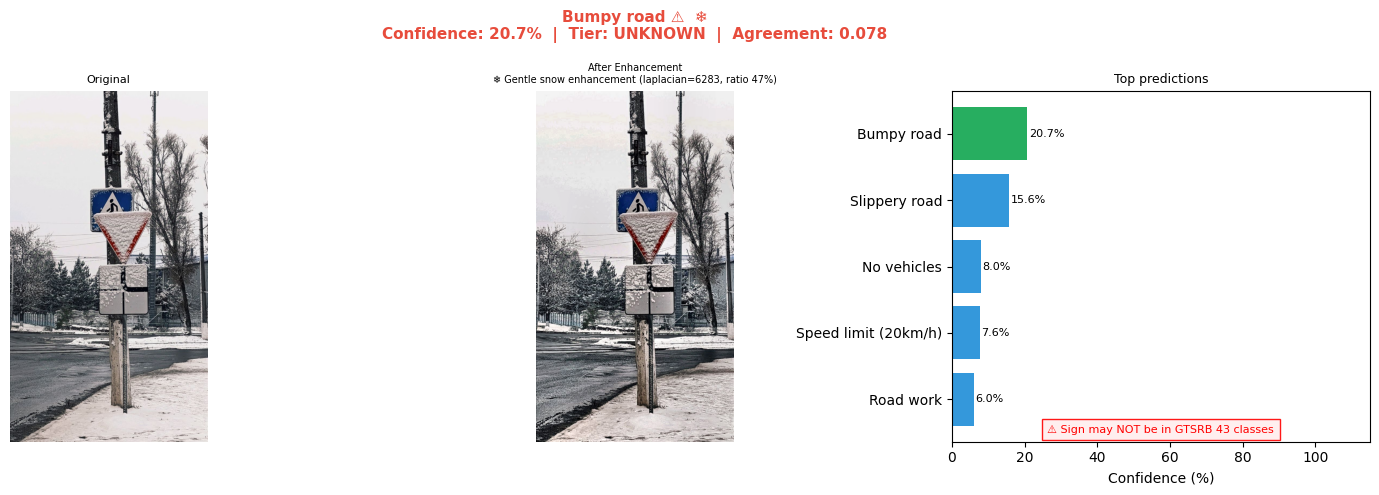


  RESULT: Bumpy road  [UNKNOWN]
  Confidence : 20.68%  (needed: 55%)
  Agreement  : 0.0776  (min: 0.1)
  Entropy    : 0.314
  Top-2 gap  : 5.1%
  Laplacian  : 6283  (sharpness — higher is sharper)
  Reliable   : ✗ NO
------------------------------------------------------------
  ⚠ WARNINGS:
    • Sign may not be in GTSRB 43 classes
------------------------------------------------------------
  Top 5 predictions:
    1. Bumpy road                              20.68% ◄
    2. Slippery road                           15.62%
    3. No vehicles                              7.98%
    4. Speed limit (20km/h)                     7.62%
    5. Road work                                5.97%


In [ ]:
# CELL 12 — PREDICT MY OWN IMAGE
#   Step 1: Smart crop (pre-cropped detection, large photo forcing)
#   Step 2: Conditional enhancement (snow/night/blurry/faded/normal)
#             - snow_on_sign only triggers on blurry images (lap < 500)
#             - night split: blurry-dark vs pure dark
#   Step 3: Smart TTA (no rotation on directional signs)
#   Step 3B: Disambiguation (23↔30, 19↔20, 23↔19, 23↔20)
#   Step 4: Reliability assessment (per-class thresholds)

!pip install -q ultralytics huggingface_hub

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2
from PIL import Image, ImageEnhance as IE
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import gdown, time, os
from pathlib import Path
from io import BytesIO
from ultralytics import YOLO



# SECTION A — CONSTANTS & YOLO SETUP


GTSRB_SIGN_TYPES = (
    "This model recognises only 43 German traffic sign classes.\n"
    "Signs outside this set will get low confidence."
)

DIRECTIONAL_SIGNS    = {19, 20, 24, 33, 34, 35, 36, 37, 38, 39}
SYMMETRIC_SIGNS      = {0, 1, 2, 3, 4, 5, 6, 7, 8, 12, 13, 14, 15, 17, 32, 41, 42}
WEATHER_HARD_CLASSES = {23, 30, 19, 20, 21, 11, 18, 27}

PER_CLASS_CONF_THRESHOLD = {
    14:0.75, 13:0.75, 12:0.75, 17:0.75, 33:0.72,
    35:0.72, 42:0.70, 10:0.70, 15:0.70, 16:0.70,
    0:0.55,  1:0.58,  2:0.58,  3:0.58,  4:0.58,
    5:0.58,  7:0.58,  8:0.58,  9:0.60,  11:0.58,
    18:0.55, 19:0.55, 20:0.55, 21:0.52, 22:0.55,
    23:0.35, # was 0.52 — snowy/hard sign, real-world images score lower
    25:0.55, 27:0.52, 28:0.55, 29:0.55,
    31:0.55, 34:0.58, 36:0.58, 37:0.58, 38:0.60,
    39:0.60, 40:0.58,
    30:0.30, # was 0.45 — ice/snow sign, hardest class
    41:0.35, # was 0.40 — hard class
    6:0.50,  24:0.50, 26:0.50, 32:0.50,
}
DEFAULT_CONF_THRESHOLD = 0.55
OUT_OF_DIST_THRESHOLD  = 0.22
AGREEMENT_THRESHOLD    = 0.10

REJECT_COCO = {0,1,2,3,4,5,6,7,8,16,17,18,19,20,21,22,23}
ACCEPT_COCO = {9,11,12}

CONFUSED_PAIRS = {
    # Ice/snow vs slippery road
    (23, 30): 'disambiguate_23_30',
    (30, 23): 'disambiguate_23_30',
    # Dangerous curve left vs right
    (19, 20): 'disambiguate_19_20',
    (20, 19): 'disambiguate_19_20',
    # Slippery road vs dangerous curve (new)
    (23, 19): 'disambiguate_23_19',
    (19, 23): 'disambiguate_23_19',
    (23, 20): 'disambiguate_23_19',
    (20, 23): 'disambiguate_23_19',
}

SIGN_YOLO_PATH = '/content/yolo_traffic_signs.pt'
if not os.path.exists(SIGN_YOLO_PATH):
    print("Downloading YOLO model...")
    try:
        from huggingface_hub import hf_hub_download
        path = hf_hub_download(
            repo_id='mshamrai/yolov8n-voc-pascal',
            filename='yolov8n-voc.pt',
            local_dir='/content'
        )
        os.rename(path, SIGN_YOLO_PATH)
        print("Downloaded ✓")
    except Exception as e:
        print(f"HuggingFace failed: {e}")
        SIGN_YOLO_PATH = 'yolov8n.pt'

try:
    yolo_model       = YOLO(SIGN_YOLO_PATH)
    USE_TRAFFIC_YOLO = 'voc' in SIGN_YOLO_PATH
    print("YOLO loaded ✓")
except Exception:
    yolo_model       = YOLO('yolov8n.pt')
    USE_TRAFFIC_YOLO = False
    print("YOLOv8n loaded ✓")



# SECTION B — STEP 1: SMART CROP

def is_precropped(img: Image.Image) -> bool:
    """Returns True if image is already a clean tight sign crop."""
    w, h    = img.size
    aspect  = max(w, h) / max(min(w, h), 1)
    max_dim = max(w, h)
    if aspect < 1.4 and max_dim < 500:
        return True
    if max_dim < 150:
        return True
    img_np     = np.array(img.convert('RGB'))
    h_np, w_np = img_np.shape[:2]
    corners    = np.array([
        img_np[0, 0], img_np[0, w_np-1],
        img_np[h_np-1, 0], img_np[h_np-1, w_np-1],
    ], dtype=np.float32)
    corner_mean = corners.mean(axis=0)
    if (corner_mean > 220).all(): return True
    if corners.std(axis=0).mean() < 20: return True
    return False


def has_real_background(img: Image.Image) -> bool:
    """Returns True if image is a real photo with background."""
    w, h    = img.size
    max_dim = max(w, h)
    if max_dim < 200:
        return False
    img_np     = np.array(img.convert('RGB'))
    h_np, w_np = img_np.shape[:2]
    bsz        = max(10, min(h_np, w_np) // 8)
    border = np.concatenate([
        img_np[:bsz,  :, :].reshape(-1,3),
        img_np[-bsz:, :, :].reshape(-1,3),
        img_np[:,  :bsz, :].reshape(-1,3),
        img_np[:, -bsz:, :].reshape(-1,3),
    ], axis=0)
    cy1, cy2 = h_np//4, 3*h_np//4
    cx1, cx2 = w_np//4, 3*w_np//4
    center   = img_np[cy1:cy2, cx1:cx2, :].reshape(-1,3)
    color_diff = np.abs(border.mean(axis=0) - center.mean(axis=0)).mean()
    total_std  = float(img_np.std())
    return color_diff > 25 or (total_std > 50 and max_dim > 400)


def detect_sign_crop(img: Image.Image):
    """Runs YOLO at multiple scales and returns best crop."""
    img_np = np.array(img.convert('RGB'))
    h, w   = img_np.shape[:2]
    all_candidates = []

    quick = yolo_model(cv2.resize(img_np,(640,640)), conf=0.15, verbose=False)[0]
    if quick.boxes is not None and len(quick.boxes) > 0:
        for box in quick.boxes:
            cls = int(box.cls[0])
            if not USE_TRAFFIC_YOLO and cls in REJECT_COCO:
                continue
            x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
            x1=int(x1*w/640); y1=int(y1*h/640)
            x2=int(x2*w/640); y2=int(y2*h/640)
            if ((x2-x1)*(y2-y1))/(w*h) > 0.55:
                return img, None, 'Full image (sign fills frame)'

    for scale in [1.0, 1.5, 2.0]:
        if scale == 1.0:
            img_try=img_np; off_x=off_y=0
        else:
            nw=int(w/scale); nh=int(h/scale)
            off_x=(w-nw)//2; off_y=(h-nh)//2
            img_try=img_np[off_y:off_y+nh, off_x:off_x+nw]
        img_r=cv2.resize(img_try,(640,640))
        sx=img_try.shape[1]/640; sy=img_try.shape[0]/640
        results=yolo_model(img_r, conf=0.10, verbose=False)[0]
        if results.boxes is not None:
            for box in results.boxes:
                cls=int(box.cls[0]); conf=float(box.conf[0])
                if not USE_TRAFFIC_YOLO and cls in REJECT_COCO:
                    continue
                x1,y1,x2,y2=box.xyxy[0].cpu().numpy()
                x1=int(x1*sx)+off_x; y1=int(y1*sy)+off_y
                x2=int(x2*sx)+off_x; y2=int(y2*sy)+off_y
                area=((x2-x1)*(y2-y1))/(w*h)
                if area<0.005 or area>0.80: continue
                score=conf*2.0 if (not USE_TRAFFIC_YOLO and cls in ACCEPT_COCO) else conf
                all_candidates.append((score,[x1,y1,x2,y2]))

    if not all_candidates:
        return None, None, 'no_detection'

    all_candidates.sort(reverse=True)
    x1,y1,x2,y2=all_candidates[0][1]
    pad=int(max(x2-x1,y2-y1)*0.15)
    x1=max(0,x1-pad); y1=max(0,y1-pad)
    x2=min(w,x2+pad); y2=min(h,y2+pad)
    side=max(x2-x1,y2-y1)
    cx=(x1+x2)//2; cy=(y1+y2)//2
    x1=max(0,cx-side//2); y1=max(0,cy-side//2)
    x2=min(w,x1+side);    y2=min(h,y1+side)
    return Image.fromarray(img_np[y1:y2,x1:x2]),(x1,y1,x2,y2),'YOLO detection'


def validate_crop(crop, original_img):
    """Reject crop if not meaningfully better than full image."""
    w_orig, h_orig = original_img.size
    w_crop, h_crop = crop.size
    crop_area = w_crop * h_crop
    full_area = w_orig * h_orig

    if crop_area > full_area * 0.85:
        return original_img, 'Full image (crop too similar to original)'

    is_large_photo = max(w_orig, h_orig) > 400
    if is_large_photo and crop_area < full_area * 0.60:
        removed = (1 - crop_area/full_area) * 100
        return crop, f'YOLO crop (forced: large photo, removed {removed:.0f}% background)'

    model.eval()
    with torch.no_grad():
        tc = VAL_TRANSFORM(crop).unsqueeze(0).to(DEVICE)
        tf = VAL_TRANSFORM(original_img).unsqueeze(0).to(DEVICE)
        cc = float(F.softmax(model(tc)['logits']*10, dim=-1).max())
        cf = float(F.softmax(model(tf)['logits']*10, dim=-1).max())

    if cc > cf * 1.05:
        return crop, f'YOLO crop (crop:{cc*100:.1f}% > full:{cf*100:.1f}%)'
    else:
        return original_img, f'Full image (full:{cf*100:.1f}% >= crop:{cc*100:.1f}%)'


def get_best_region(img_original, use_detector=True):
    if not use_detector:
        return img_original, None, 'Full image (detection disabled)'

    w, h    = img_original.size
    max_dim = max(w, h)

    # Any image larger than 500px is a real photo — always run YOLO
   
    if max_dim > 500:
        crop, box_coords, method = detect_sign_crop(img_original)
        if crop is None:
            return img_original, None, 'Full image (YOLO found nothing)'
        final_img, final_method = validate_crop(crop, img_original)
        final_box = box_coords if final_img is crop else None
        return final_img, final_box, final_method

    # Small images — use heuristics
    if is_precropped(img_original):
        return img_original, None, 'Full image (pre-cropped sign detected)'
    if not has_real_background(img_original):
        return img_original, None, 'Full image (no background detected)'

    crop, box_coords, method = detect_sign_crop(img_original)
    if crop is None:
        return img_original, None, 'Full image (YOLO found nothing)'
    final_img, final_method = validate_crop(crop, img_original)
    final_box = box_coords if final_img is crop else None
    return final_img, final_box, final_method


# SECTION C — STEP 2: CONDITIONAL ENHANCEMENT

def measure_image(img: Image.Image) -> dict:
    """
    Measures image quality metrics.
    Laplacian variance = sharpness:
      < 100  → very blurry
      100-500 → moderately sharp
      > 500  → sharp/very sharp
    """
    img_rgb   = np.array(img.convert('RGB'))
    img_hsv   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    img_gray  = np.array(img.convert('L'))
    h, w      = img_rgb.shape[:2]
    snow_mask = (img_hsv[:,:,1] < 30) & (img_hsv[:,:,2] > 200)
    return {
        'brightness' : float(img_gray.mean()),
        'contrast'   : float(img_gray.std()),
        'saturation' : float(img_hsv[:,:,1].mean()),
        'laplacian'  : float(cv2.Laplacian(img_gray, cv2.CV_64F).var()),
        'snow_ratio' : float(snow_mask.sum()) / (h * w),
        'height'     : h,
        'width'      : w,
    }


def classify_condition(m: dict) -> str:
    b, c, s, sr = m['brightness'], m['contrast'], m['saturation'], m['snow_ratio']
    h, w        = m['height'], m['width']
    max_dim     = max(h, w)
    lap         = m['laplacian']

    if b < 70 and c < 45 and lap >= 100:
        return 'night'

    if b < 110 and lap < 100:
        return 'night_blurry'

    # overexposed AND desaturated = snow-washed sign
    # brightness > 210 but saturation very low means snow is
    # washing out the colors, not genuine overexposure
    if b > 210 and s < 35:
        return 'snowy'

    if sr > 0.20 and b < 220 and s < 65:
        return 'snowy'

    if s < 55 and 70 < b < 195:
        return 'snowy'

    if c < 35 and b > 100 and s < 70:
        return 'snowy'

    if max_dim < 250 and s < 80 and c < 50 and b > 80:
        return 'snowy'

    if lap < 200:
        return 'blurry'

    if s < 55 and 100 < b < 200 and c < 40:
        return 'faded'

    if 70 <= b < 115 and c > 25:
        return 'mildly_dark'

    if b > 210:
        return 'overexposed'

    return 'normal'


def apply_enhancement(img: Image.Image, condition: str, m: dict):
    """
    Applies targeted enhancement only when needed.
    Handles: night, night_blurry, snowy, blurry, faded, mildly_dark.
    Key fix: snow_on_sign only triggers aggressive enhancement
             when image is also blurry (lap < 500).
             Sharp snowy images get gentle enhancement only.
    """
    if condition in ('normal', 'overexposed'):
        label = 'No enhancement needed' if condition == 'normal' \
                else 'No enhancement (already bright)'
        return img, False, label

    if condition == 'night':
        # Pure dark scene — CLAHE works well
        img_np     = np.array(img.convert('RGB'))
        lab        = cv2.cvtColor(cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2LAB)
        l, a, b_ch = cv2.split(lab)
        l          = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(l)
        out        = Image.fromarray(cv2.cvtColor(cv2.merge([l, a, b_ch]), cv2.COLOR_LAB2RGB))
        out        = IE.Brightness(out).enhance(1.20)
        out        = IE.Contrast(out).enhance(1.15)
        return out, True, f'🌙 Night enhancement (brightness={m["brightness"]:.0f}, laplacian={m["laplacian"]:.0f})'

    if condition == 'night_blurry':
        # Dark AND blurry — CLAHE makes blur worse, use sharpen-first
        img_np = np.array(img.convert('RGB'))
        blur   = cv2.GaussianBlur(img_np, (0, 0), sigmaX=3)
        sharp  = cv2.addWeighted(img_np, 1.4, blur, -0.4, 0)
        out    = Image.fromarray(np.clip(sharp, 0, 255).astype(np.uint8))
        out    = IE.Sharpness(out).enhance(1.8)
        out    = IE.Brightness(out).enhance(1.30)
        out    = IE.Contrast(out).enhance(1.10)
        return out, True, f'🌙🔍 Dark+blur enhancement (brightness={m["brightness"]:.0f}, laplacian={m["laplacian"]:.0f})'

    if condition == 'snowy':
        img_np     = np.array(img.convert('RGB'))
        h, w       = img_np.shape[:2]
        lap        = m['laplacian']

        # snow_on_sign: small crop + snow visible + ALSO blurry (lap < 500)
        # Sharp images (lap >= 500) don't need aggressive enhancement —
        # it destroys sign detail instead of helping
        snow_on_sign = (max(h, w) < 400) and (m['snow_ratio'] > 0.05) and (lap < 500)

        lab        = cv2.cvtColor(cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2LAB)
        l, a, b_ch = cv2.split(lab)
        clip       = 3.5 if snow_on_sign else 2.0
        l          = cv2.createCLAHE(clipLimit=clip, tileGridSize=(6,6)).apply(l)
        out        = Image.fromarray(cv2.cvtColor(cv2.merge([l, a, b_ch]), cv2.COLOR_LAB2RGB))

        if snow_on_sign:
            out  = IE.Contrast(out).enhance(1.35)
            out  = IE.Color(out).enhance(1.25)
            out  = IE.Sharpness(out).enhance(1.20)
            desc = f'❄ Strong snow enhancement (snow on sign, laplacian={lap:.0f}, ratio {m["snow_ratio"]:.0%})'
        else:
            # Gentle — preserves detail on sharp snowy images
            out  = IE.Contrast(out).enhance(1.08)
            out  = IE.Sharpness(out).enhance(1.05)
            desc = f'❄ Gentle snow enhancement (laplacian={lap:.0f}, ratio {m["snow_ratio"]:.0%})'
        return out, True, desc

    if condition == 'blurry':
        img_np = np.array(img.convert('RGB'))
        blur   = cv2.GaussianBlur(img_np, (0, 0), sigmaX=3)
        sharp  = cv2.addWeighted(img_np, 1.5, blur, -0.5, 0)
        out    = Image.fromarray(np.clip(sharp, 0, 255).astype(np.uint8))
        out    = IE.Sharpness(out).enhance(2.0)
        out    = IE.Contrast(out).enhance(1.10)
        return out, True, f'🔍 Blur enhancement (laplacian={m["laplacian"]:.0f})'

    if condition == 'faded':
        out = IE.Color(img).enhance(1.20)
        out = IE.Contrast(out).enhance(1.15)
        out = IE.Sharpness(out).enhance(1.08)
        return out, True, f'🔆 Faded sign enhancement (saturation={m["saturation"]:.0f})'

    if condition == 'mildly_dark':
        bf  = 1.0 + min(0.15, (115 - m['brightness']) / 115 * 0.20)
        out = IE.Brightness(img).enhance(bf)
        out = IE.Contrast(out).enhance(1.08)
        return out, True, f'🔆 Mild dark enhancement (brightness={m["brightness"]:.0f}, boost x{bf:.2f})'

    return img, False, 'No enhancement (fallback)'


def smart_enhance(img: Image.Image):
    """Master enhancement function."""
    m         = measure_image(img)
    condition = classify_condition(m)
    enhanced, was_enhanced, desc = apply_enhancement(img, condition, m)
    return enhanced, was_enhanced, desc, condition, m



# SECTION D — STEP 3: SMART TTA


def get_tta_variants(img: Image.Image, predicted_class: int) -> tuple:
    """Returns TTA variants appropriate for the sign type."""
    if predicted_class in DIRECTIONAL_SIGNS:
        variants = [
            ('base',      img),
            ('bright+',   IE.Brightness(img).enhance(1.08)),
            ('bright-',   IE.Brightness(img).enhance(0.93)),
            ('contrast+', IE.Contrast(img).enhance(1.08)),
            ('contrast-', IE.Contrast(img).enhance(0.93)),
            ('sharp+',    IE.Sharpness(img).enhance(1.10)),
        ]
        group = 'directional (no rotation)'
    elif predicted_class in SYMMETRIC_SIGNS:
        variants = [
            ('base',      img),
            ('rot_-8',    img.rotate(-8, expand=False)),
            ('rot_+8',    img.rotate(+8, expand=False)),
            ('rot_-5',    img.rotate(-5, expand=False)),
            ('rot_+5',    img.rotate(+5, expand=False)),
            ('bright+',   IE.Brightness(img).enhance(1.08)),
            ('bright-',   IE.Brightness(img).enhance(0.93)),
            ('contrast+', IE.Contrast(img).enhance(1.08)),
        ]
        group = 'symmetric (full rotation)'
    else:
        variants = [
            ('base',      img),
            ('rot_-5',    img.rotate(-5, expand=False)),
            ('rot_+5',    img.rotate(+5, expand=False)),
            ('bright+',   IE.Brightness(img).enhance(1.08)),
            ('bright-',   IE.Brightness(img).enhance(0.93)),
            ('contrast+', IE.Contrast(img).enhance(1.08)),
        ]
        group = 'conservative (small rotation)'
    return variants, group


@torch.no_grad()
def smart_tta_predict(img: Image.Image, top_k=5):
    """Two-pass TTA: quick predict → choose TTA group → full TTA."""
    model.eval()
    t0          = VAL_TRANSFORM(img).unsqueeze(0).to(DEVICE)
    out0        = model(t0)
    rough_class = int(F.softmax(out0['logits']*10, dim=-1).argmax(dim=-1)[0])

    variants, tta_group = get_tta_variants(img, rough_class)
    probs_list  = []
    agreements  = []

    for _, variant in variants:
        tensor = VAL_TRANSFORM(variant).unsqueeze(0).to(DEVICE)
        out    = model(tensor)
        probs  = F.softmax(out['logits']*10, dim=-1)
        probs_list.append(probs)
        agreements.append(float(out['capsule_agreement'][0]))

    mean_probs        = torch.mean(torch.stack(probs_list, dim=0), dim=0)[0]
    top_vals, top_ids = mean_probs.topk(top_k)
    pred      = int(top_ids[0])
    conf      = float(top_vals[0])
    agreement = float(np.mean(agreements))

    return pred, conf, agreement, top_vals, top_ids, tta_group



# SECTION D2 — STEP 3B: DISAMBIGUATION


def disambiguate_23_30(img: Image.Image) -> int:
    """
    Decides between class 23 (Slippery road) and 30 (Beware ice/snow).
    Snowflake → strong 6-fold rotational symmetry → class 30.
    Car skid  → clear diagonal asymmetry          → class 23.

    Key fix: raised symmetry threshold from 0.72 to 0.78.
    Snow covering the sign creates false symmetry — need stronger
    evidence before declaring snowflake.
    Default to 23 (slippery road) when uncertain — it's more common.
    """
    w, h   = img.size
    margin = int(min(w, h) * 0.25)   # larger margin to cut border noise
    center = img.crop((margin, margin, w-margin, h-margin))
    gray   = np.array(center.convert('L'), dtype=np.float32)
    gray   = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)

    def rotation_similarity(angle):
        h_g, w_g = gray.shape
        M        = cv2.getRotationMatrix2D((w_g/2, h_g/2), angle, 1.0)
        rotated  = cv2.warpAffine(gray, M, (w_g, h_g))
        return 1.0 - np.abs(gray - rotated).mean()

    # Snowflake has 6-fold symmetry — check at 60° AND 120° AND 30°
    sim_60  = rotation_similarity(60)
    sim_120 = rotation_similarity(120)
    sim_30  = rotation_similarity(30)

    # All three must agree for snowflake — car skid fails at 120°
    symmetry_score = (sim_60 + sim_120 + sim_30) / 3

    h_g, w_g      = gray.shape
    cb = float(gray[h_g//3:2*h_g//3, w_g//3:2*w_g//3].mean())

    # Stricter threshold: 0.78 (was 0.72) — snow creates false symmetry
    if symmetry_score > 0.78:   return 30   # clear snowflake
    elif symmetry_score < 0.65: return 23   # clear car skid
    else:                       return 23   # default to 23 when uncertain
    #                                         (slippery road is more common)
def disambiguate_19_20(img: Image.Image) -> int:
    """
    Decides between class 19 (Dangerous curve LEFT) and 20 (RIGHT).
    Checks which side of the sign has more content.
    """
    w, h  = img.size
    gray  = np.array(img.convert('L'), dtype=np.float32)
    inner = gray[int(h*0.20):int(h*0.80), int(w*0.15):int(w*0.85)]
    h_i, w_i = inner.shape
    return 19 if inner[:, :w_i//2].mean() > inner[:, w_i//2:].mean() else 20


def disambiguate_23_19(img: Image.Image) -> int:
    """
    Decides between class 23 (Slippery road) and 19/20 (Dangerous curve).
    Slippery road has a car + skid marks = multiple components.
    Dangerous curve has a single continuous arrow = fewer components.
    Uses connected component analysis on the inner triangle region.
    """
    w, h   = img.size
    margin = int(min(w, h) * 0.25)
    inner  = img.crop((margin, margin, w-margin, h-margin))
    gray   = np.array(inner.convert('L'))

    # Threshold to isolate dark symbol from background
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Count connected components
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(binary)
    h_i, w_i  = gray.shape
    min_area  = h_i * w_i * 0.01   # ignore tiny noise blobs
    real_components = sum(
        1 for i in range(1, num_labels)
        if stats[i, cv2.CC_STAT_AREA] > min_area
    )

    # Slippery road: car body + skid marks = typically 3+ components
    # Dangerous curve: single arrow = typically 1-2 components
    return 23 if real_components >= 3 else 19


# Classes that get confused with 23/30 in overexposed/snow conditions
SNOW_ADJACENT_CLASSES = {19, 20, 21, 18, 23, 30}

def try_disambiguate(pred, top_ids, top_vals, img: Image.Image):
    top1         = int(top_ids[0])
    top_ids_list = [int(i) for i in top_ids]

    if len(top_ids) < 2:
        return pred, False, ''

    top2 = int(top_ids[1])
    gap  = float(top_vals[0]) - float(top_vals[1])

    #  23↔30: always run when top1 is 23 or 30 
    if top1 in {23, 30}:
        result = disambiguate_23_30(img)
        note   = (f'Disambiguated 23↔30 via symmetry → '
                  f'class {result} ({GTSRB_CLASS_NAMES[result]})')
        return result, True, note

    #  Also run if both 23 and 30 appear anywhere in top-5 
    if 23 in top_ids_list and 30 in top_ids_list:
        result = disambiguate_23_30(img)
        note   = (f'Disambiguated 23↔30 via symmetry (both in top-5) → '
                  f'class {result} ({GTSRB_CLASS_NAMES[result]})')
        return result, True, note

    # top1 is snow-adjacent AND 23 appears in top-5 
    # Handles overexposed/washed-out signs where model guesses
    # curve/caution but the sign might actually be class 23 or 30
    if top1 in SNOW_ADJACENT_CLASSES and 23 in top_ids_list:
        result = disambiguate_23_30(img)
        note   = (f'Disambiguated 23↔30 via symmetry (snow-adjacent top1) → '
                  f'class {result} ({GTSRB_CLASS_NAMES[result]})')
        return result, True, note

    if top1 in SNOW_ADJACENT_CLASSES and 30 in top_ids_list:
        result = disambiguate_23_30(img)
        note   = (f'Disambiguated 23↔30 via symmetry (snow-adjacent top1) → '
                  f'class {result} ({GTSRB_CLASS_NAMES[result]})')
        return result, True, note

    #  All other pairs: only when model is genuinely unsure 
    if gap > 0.25:
        return pred, False, ''

    pair = (top1, top2)
    if pair not in CONFUSED_PAIRS:
        return pred, False, ''

    func_name = CONFUSED_PAIRS[pair]

    if func_name == 'disambiguate_19_20':
        result = disambiguate_19_20(img)
        return result, True, (f'Disambiguated 19↔20 via side analysis → '
                              f'class {result} ({GTSRB_CLASS_NAMES[result]})')

    if func_name == 'disambiguate_23_19':
        result = disambiguate_23_19(img)
        return result, True, (f'Disambiguated 23↔19/20 via components → '
                              f'class {result} ({GTSRB_CLASS_NAMES[result]})')

    return pred, False, ''


# SECTION E — STEP 4: RELIABILITY ASSESSMENT


def assess_reliability(pred, conf, agreement, top_vals, top_ids):
    """Assesses prediction reliability using 5 checks."""
    warnings    = []
    conf_needed = PER_CLASS_CONF_THRESHOLD.get(pred, DEFAULT_CONF_THRESHOLD)
    probs       = np.clip(top_vals.cpu().numpy(), 1e-10, 1.0)
    entropy     = float(-np.sum(probs*np.log(probs)) / np.log(43))
    vals        = top_vals.cpu().numpy()
    top2gap     = float(vals[0]-vals[1]) if len(vals) >= 2 else 1.0
    agreement_min = 0.07 if pred in WEATHER_HARD_CLASSES else AGREEMENT_THRESHOLD

    if conf < OUT_OF_DIST_THRESHOLD:
        return {
            'tier':'UNKNOWN', 'color':'#E74C3C', 'reliable':False,
            'conf_needed':conf_needed, 'entropy':entropy, 'top2_gap':top2gap,
            'warnings':['Sign may not be in GTSRB 43 classes'],
            'reason':f'Confidence {conf*100:.1f}% below OOD threshold {OUT_OF_DIST_THRESHOLD*100:.0f}%',
        }
    if conf < conf_needed:
        warnings.append(f'Confidence {conf*100:.1f}% below expected {conf_needed*100:.0f}% for this sign type')
    if agreement < agreement_min:
        warnings.append(f'Capsule agreement {agreement:.3f} below minimum {agreement_min:.2f}')
    if entropy > 0.55:
        warnings.append(f'High entropy {entropy:.2f} — model spread across many classes')
    if top2gap < 0.15:
        second = GTSRB_CLASS_NAMES.get(int(top_ids[1]),'unknown') if len(top_ids)>1 else ''
        warnings.append(f'Small gap to 2nd place ({top2gap*100:.1f}%) — could also be "{second}"')

    n = len(warnings)
    if   n == 0 and conf >= 0.85 and agreement >= 0.15:
        tier, color = 'HIGH',   '#27AE60'
    elif n <= 1 and conf >= conf_needed and agreement >= agreement_min:
        tier, color = 'MEDIUM', '#2980B9'
    else:
        tier, color = 'LOW',    '#F39C12'

    return {
        'tier':tier, 'color':color, 'reliable':tier in ('HIGH','MEDIUM'),
        'conf_needed':conf_needed, 'entropy':entropy, 'top2_gap':top2gap,
        'warnings':warnings,
        'reason':' | '.join(warnings) if warnings
                 else f'Confident ({conf*100:.1f}%, agreement {agreement:.3f})',
    }



# SECTION F — MAIN PREDICTION FUNCTION


def predict_one_image(image_source, top_k=5, use_detector=True):
    """Full prediction pipeline — Steps 1 → 2 → 3 → 3B → 4 → display."""

    if isinstance(image_source, (str, Path)):
        img_original = Image.open(image_source).convert('RGB')
    else:
        img_original = image_source.convert('RGB')

    print(f"\nImage size: {img_original.size[0]}×{img_original.size[1]} px")

    #  STEP 1: Smart crop 
    img_region, box_coords, detection_method = get_best_region(
        img_original, use_detector=use_detector
    )
    print(f"Detection  : {detection_method}")

    #  STEP 2: Conditional enhancement 
    img_enhanced, was_enhanced, enhance_desc, condition, metrics = smart_enhance(img_region)
    print(f"Condition  : {condition}  "
          f"(laplacian={metrics['laplacian']:.0f}, "
          f"brightness={metrics['brightness']:.0f}, "
          f"saturation={metrics['saturation']:.0f})")
    print(f"Enhancement: {enhance_desc}")

    #  STEP 3: Smart TTA 
    pred, conf, agreement, top_vals, top_ids, tta_group = smart_tta_predict(
        img_enhanced, top_k=top_k
    )
    print(f"TTA group  : {tta_group}")

    #  STEP 3B: Disambiguation 
    pred_disambig, was_disambiguated, disambig_note = try_disambiguate(
        pred, top_ids, top_vals, img_enhanced
    )
    if was_disambiguated:
        print(f"Disambiguation: {disambig_note}")
        pred = pred_disambig

    #  STEP 4: Reliability assessment 
    assessment = assess_reliability(pred, conf, agreement, top_vals, top_ids)
    tier     = assessment['tier']
    color    = assessment['color']
    reliable = assessment['reliable']
    warnings = assessment['warnings']

    #  Display 
    n_panels = 3 if was_enhanced else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 5))
    panel = 0

    axes[panel].imshow(img_original)
    title = 'Original'
    if box_coords is not None:
        x1,y1,x2,y2 = box_coords
        rect = patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=3, edgecolor='#27AE60', facecolor='none'
        )
        axes[panel].add_patch(rect)
        axes[panel].text(
            x1, max(0,y1-8), 'Sign detected',
            color='#27AE60', fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )
        title = f'Original\n({detection_method})'
    axes[panel].set_title(title, fontsize=8)
    axes[panel].axis('off')
    panel += 1

    if was_enhanced:
        axes[panel].imshow(img_enhanced)
        axes[panel].set_title(f'After Enhancement\n{enhance_desc}', fontsize=7)
        axes[panel].axis('off')
        panel += 1

    names      = [GTSRB_CLASS_NAMES[int(i)][:28] for i in top_ids]
    values     = [float(v)*100 for v in top_vals]
    bar_colors = ['#27AE60' if i==0 else '#3498DB' for i in range(len(names))]
    axes[panel].barh(names[::-1], values[::-1], color=bar_colors[::-1])
    axes[panel].set_xlabel('Confidence (%)')
    axes[panel].set_title('Top predictions', fontsize=9)
    axes[panel].set_xlim(0, 115)
    for i, v in enumerate(values[::-1]):
        axes[panel].text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=8)
    if tier == 'UNKNOWN':
        axes[panel].text(
            0.5, 0.02, "⚠ Sign may NOT be in GTSRB 43 classes",
            transform=axes[panel].transAxes, fontsize=8,
            color='red', ha='center', va='bottom',
            bbox=dict(facecolor='#FFEEEE', edgecolor='red', alpha=0.9)
        )
    if was_disambiguated:
        axes[panel].text(
            0.5, 0.98, f"🔍 {disambig_note}",
            transform=axes[panel].transAxes, fontsize=7,
            color='#8E44AD', ha='center', va='top',
            bbox=dict(facecolor='#F5EEF8', edgecolor='#8E44AD', alpha=0.9)
        )

    warn_icon = ' ⚠' if not reliable else ''
    cond_icon = {
        'night':'🌙', 'night_blurry':'🌙🔍', 'snowy':'❄',
        'blurry':'🔍', 'faded':'🔆', 'mildly_dark':'🔆',
        'normal':'',   'overexposed':''
    }.get(condition, '')
    plt.suptitle(
        f'{GTSRB_CLASS_NAMES[pred]}{warn_icon}  {cond_icon}\n'
        f'Confidence: {conf*100:.1f}%  |  Tier: {tier}  |  Agreement: {agreement:.3f}',
        fontsize=11, fontweight='bold', color=color
    )
    plt.tight_layout()
    fig_path = PREDICTION_DIR / f'prediction_{int(time.time())}.png'
    plt.savefig(str(fig_path), dpi=120, bbox_inches='tight')
    plt.show()

    #  Printed report 
    print("\n" + "="*60)
    print(f"  RESULT: {GTSRB_CLASS_NAMES[pred]}  [{tier}]")
    print(f"  Confidence : {conf*100:.2f}%  (needed: {assessment['conf_needed']*100:.0f}%)")
    print(f"  Agreement  : {agreement:.4f}  (min: {0.07 if pred in WEATHER_HARD_CLASSES else AGREEMENT_THRESHOLD})")
    print(f"  Entropy    : {assessment['entropy']:.3f}")
    print(f"  Top-2 gap  : {assessment['top2_gap']*100:.1f}%")
    print(f"  Laplacian  : {metrics['laplacian']:.0f}  (sharpness — higher is sharper)")
    print(f"  Reliable   : {'✓ YES' if reliable else '✗ NO'}")
    if was_disambiguated:
        print(f"  Disambig   : {disambig_note}")
    if warnings:
        print("-"*60)
        print("  ⚠ WARNINGS:")
        for w in warnings:
            print(f"    • {w}")
    print("-"*60)
    print(f"  Top {top_k} predictions:")
    for rank,(v,idx) in enumerate(zip(top_vals,top_ids),1):
        marker = " ◄" if rank==1 else ""
        print(f"    {rank}. {GTSRB_CLASS_NAMES[int(idx)]:<38} {float(v)*100:>6.2f}%{marker}")
    print("="*60)

    return pred, conf, agreement, assessment



# SECTION G — INPUT / RUN

INPUT_METHOD = 'upload'   # 'upload' | 'drive_link' | 'drive_path'
USE_DETECTOR = True

if INPUT_METHOD == 'upload':
    from google.colab import files
    print("Select your traffic sign image...")
    uploaded = files.upload()
    for filename, data in uploaded.items():
        print(f"\nProcessing: {filename}")
        img = Image.open(BytesIO(data)).convert('RGB')
        predict_one_image(img, use_detector=USE_DETECTOR)

elif INPUT_METHOD == 'drive_link':
    SHARE_LINK = 'PASTE_YOUR_LINK_HERE'
    file_id    = SHARE_LINK.split('/d/')[1].split('/')[0]
    out_path   = f'/content/test_sign_{int(time.time())}.jpg'
    gdown.download(f'https://drive.google.com/uc?id={file_id}',
                   out_path, quiet=False, fuzzy=True)
    predict_one_image(out_path, use_detector=USE_DETECTOR)

elif INPUT_METHOD == 'drive_path':
    IMAGE_PATH = '/content/drive/MyDrive/sign.jpg'
    predict_one_image(IMAGE_PATH, use_detector=USE_DETECTOR)

# CELL 13 — QUICK CHECK

Upload your test dataset ZIP...


Saving test_dataset.zip to test_dataset (3).zip
Found 66 images across 13 classes

Loading models...
V1/V2 model loaded ✓
V3 model loaded ✓

Running V1 predictions (no pipeline)...
  Error on ._Speed limit 30 km:h.png: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/1/._Speed limit 30 km:h.png'
  Error on ._Stop13.jpg: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/14/._Stop13.jpg'
  Error on ._sign.jpg: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/14/._sign.jpg'
  Error on ._Stop4.jpg: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/14/._Stop4.jpg'
  Error on ._Stop6.jpg: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/14/._Stop6.jpg'
  Error on ._Stop8.jpg: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/14/._Stop8.jpg'
  Error on ._Stop2.jpg: cannot identify image file '/content/test_dataset/__MACOSX/test_dataset/14/._Stop2.jpg'
  Error 

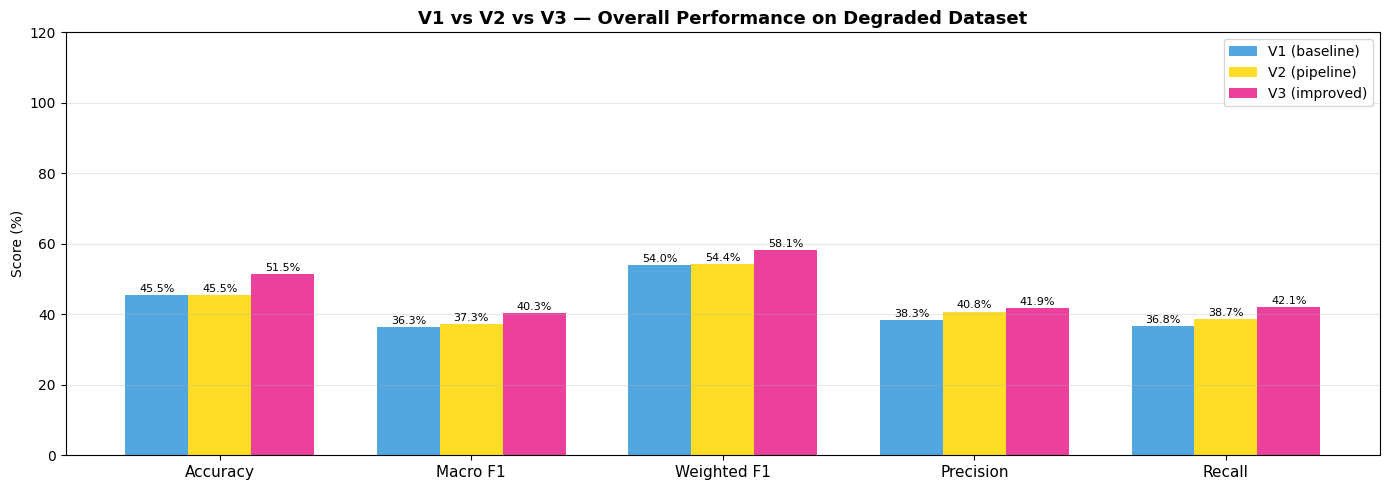

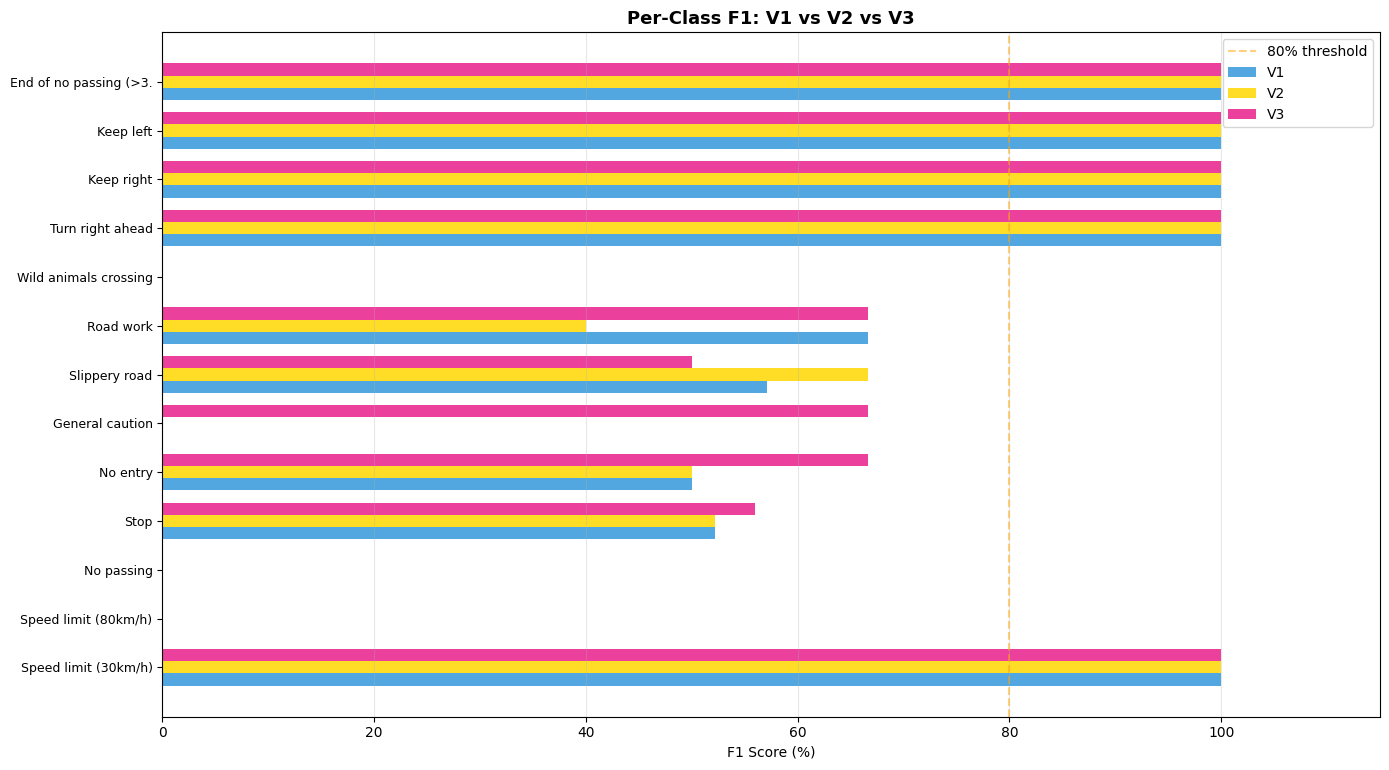

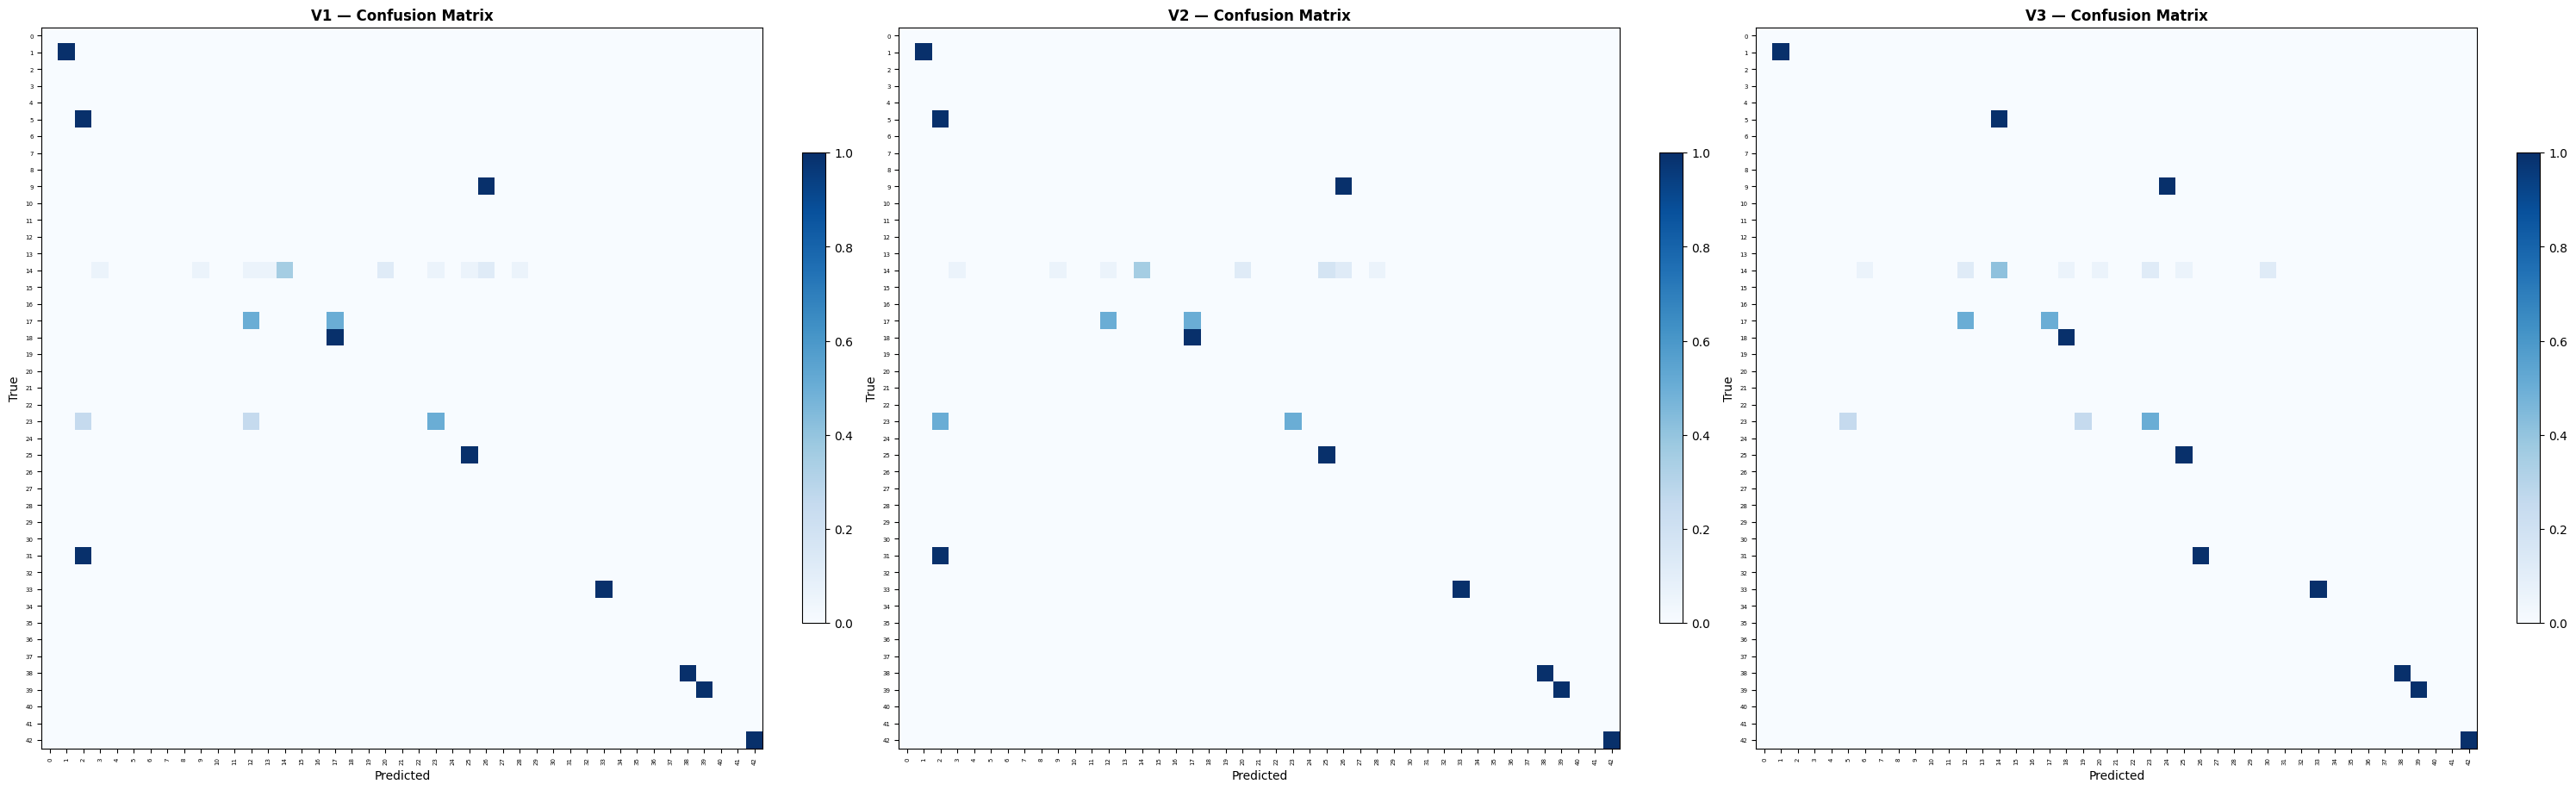

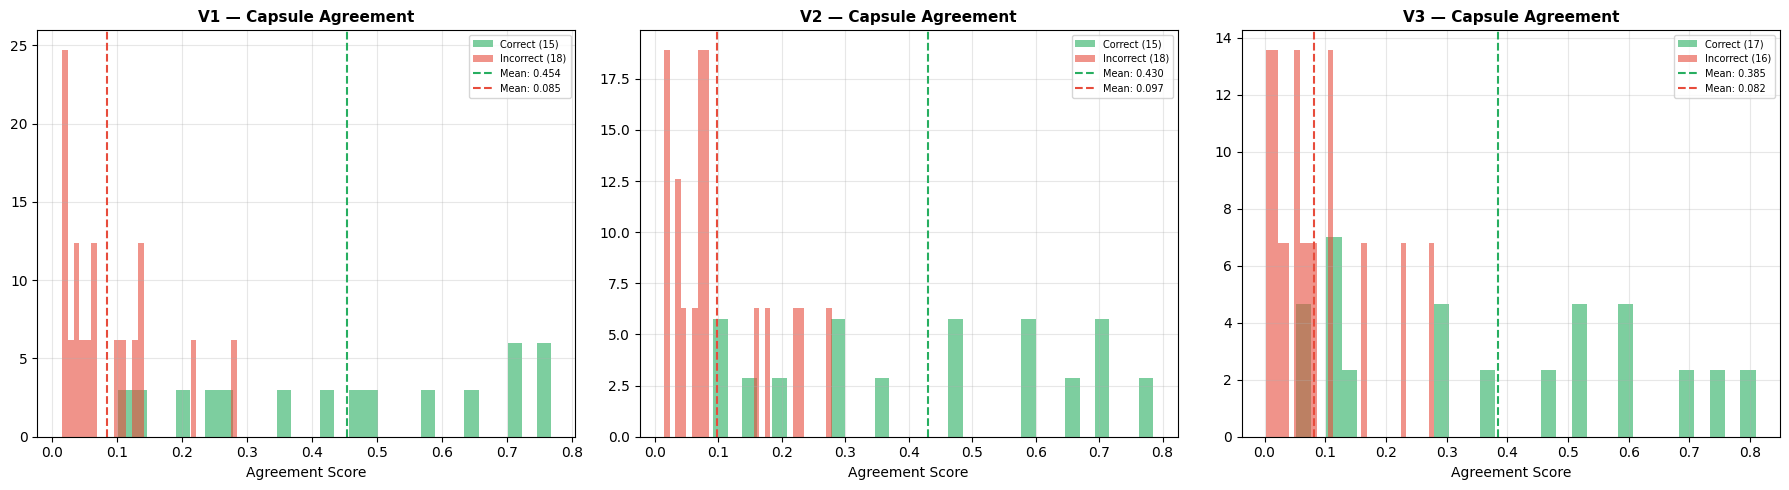

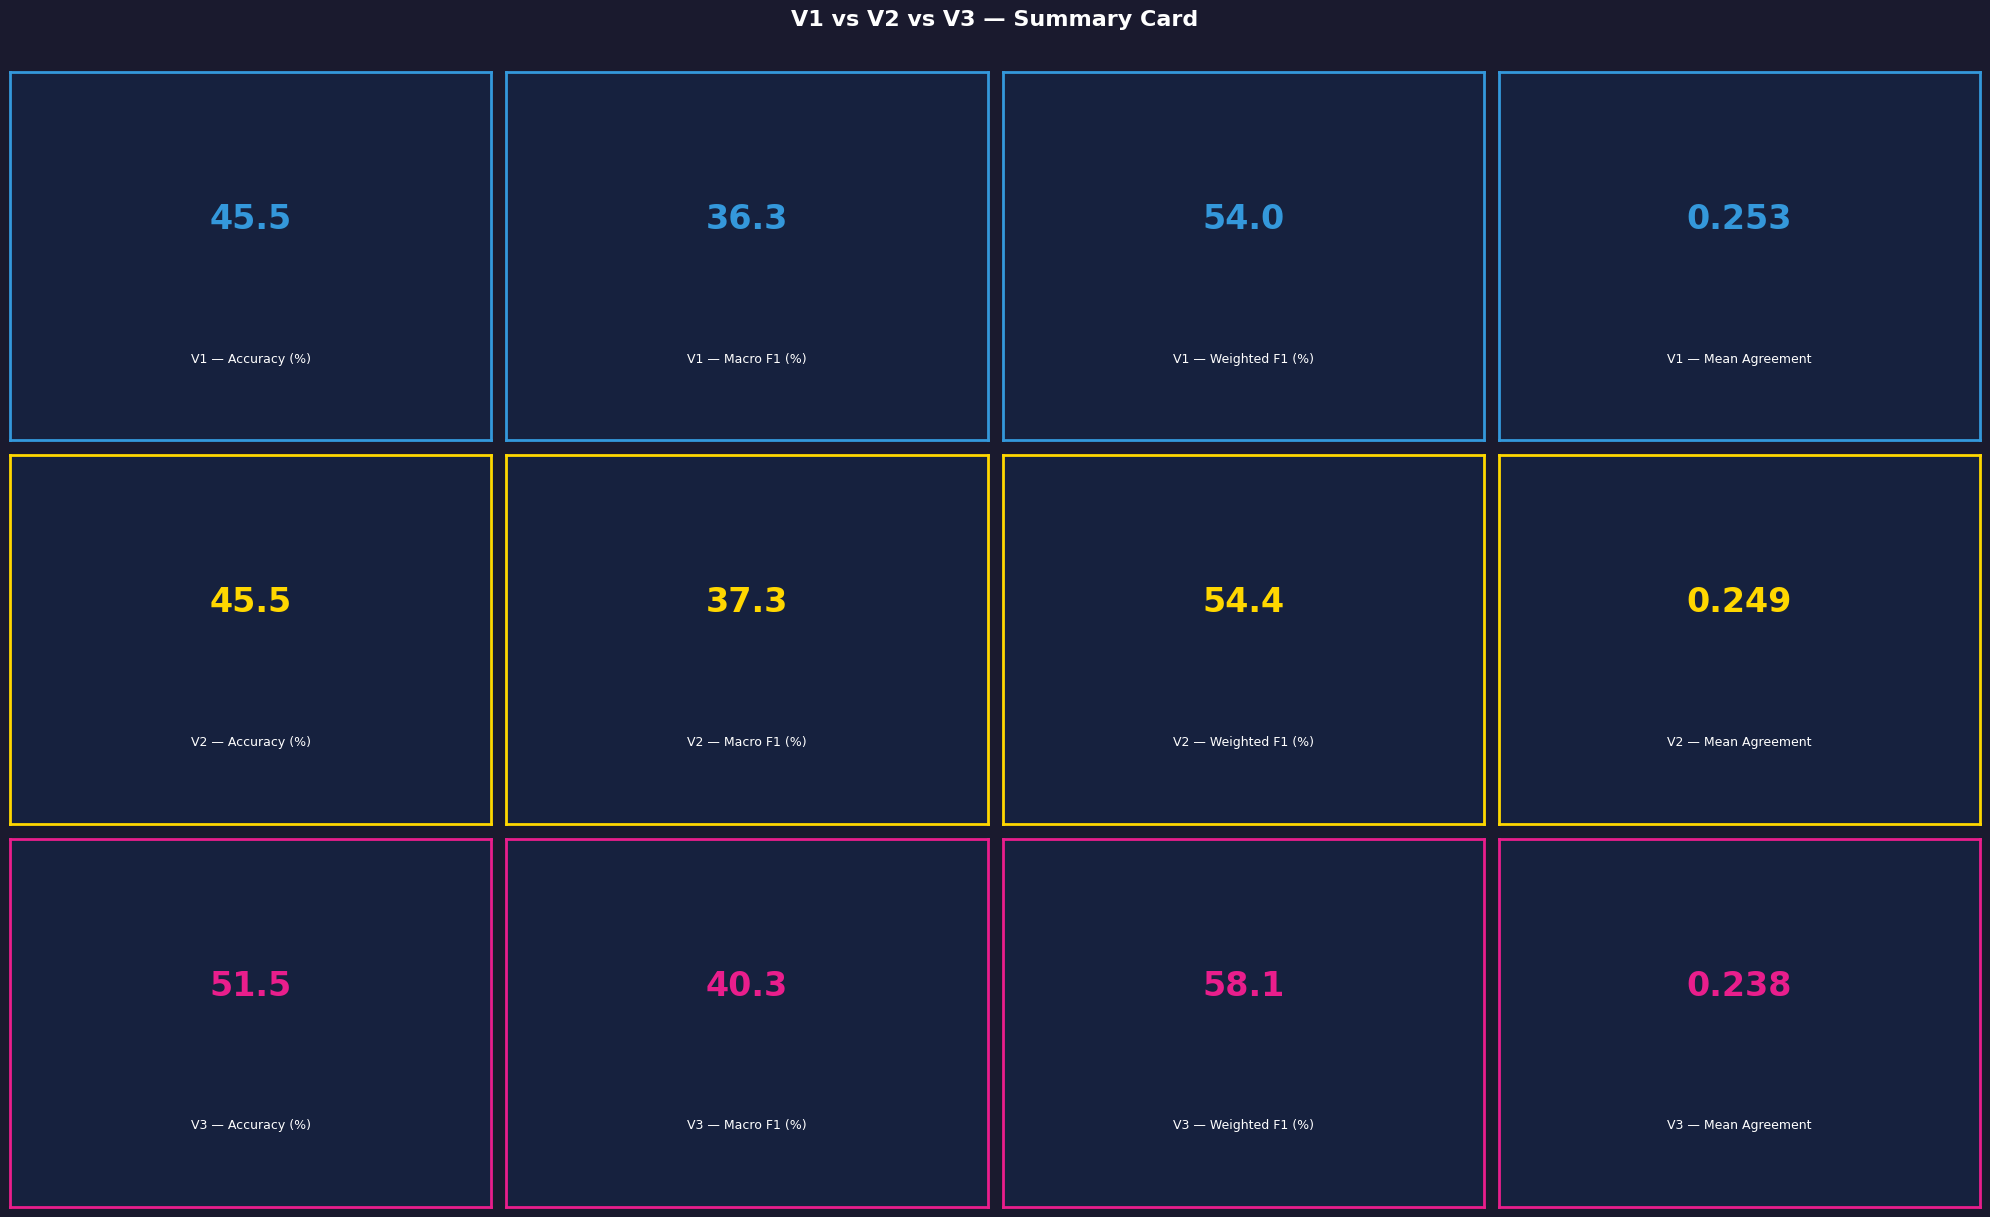


  RESULTS SAVED TO: /content/drive/MyDrive/V1_V2_V3_comparison
  V1  45.5%  (15/33)  baseline, no pipeline
  V2  45.5%  (15/33)  same model + pipeline
  V3  51.5%  (17/33)  improved model + pipeline

  Best accuracy on your dataset: V3 (51.5%) 🏆


In [ ]:

# CELL — V1 vs V2 vs V3 COMPARISON ON CUSTOM TEST DATASET

# V1 = baseline model, no pipeline
# V2 = same model as V1, with enhancement + TTA pipeline
# V3 = improved model (WeightedMarginLoss), with pipeline


!pip install -q scikit-learn

import os, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance as IE
import cv2
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)
from google.colab import files as colab_files

#  Paths 
V1_V2_CKPT = Path('/content/drive/MyDrive/TrafficSign_EfficientCaps/EfficientCaps/checkpoints/best_model.pt')
V3_CKPT    = Path('/content/drive/MyDrive/TrafficSign_EfficientCaps_V3/EfficientCaps/checkpoints/best_model.pt')
SAVE_DIR   = Path('/content/drive/MyDrive/V1_V2_V3_comparison')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE    = 48
NUM_CLASSES = 43

GTSRB_CLASS_NAMES = {
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)', 3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)', 9:'No passing',
    10:'No passing (>3.5t)', 11:'Right-of-way at intersection',
    12:'Priority road', 13:'Yield', 14:'Stop',
    15:'No vehicles', 16:'Vehicles > 3.5t prohibited',
    17:'No entry', 18:'General caution',
    19:'Dangerous curve (left)', 20:'Dangerous curve (right)',
    21:'Double curve', 22:'Bumpy road', 23:'Slippery road',
    24:'Road narrows (right)', 25:'Road work',
    26:'Traffic signals', 27:'Pedestrians',
    28:'Children crossing', 29:'Bicycles crossing',
    30:'Beware of ice/snow', 31:'Wild animals crossing',
    32:'End of all restrictions', 33:'Turn right ahead',
    34:'Turn left ahead', 35:'Go straight',
    36:'Go straight or right', 37:'Go straight or left',
    38:'Keep right', 39:'Keep left',
    40:'Roundabout mandatory', 41:'End of no passing',
    42:'End of no passing (>3.5t)',
}

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337,0.3064,0.3171],[0.2672,0.2564,0.2629]),
])


#  Architecture — identical in V1, V2, V3 
class DepthwiseSeparableConvLocal(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch,in_ch,kernel_size,stride,padding,groups=in_ch,bias=False)
        self.pointwise = nn.Conv2d(in_ch,out_ch,1,bias=False)
        self.bn        = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return F.relu(self.bn(self.pointwise(self.depthwise(x))), inplace=True)

class PrimaryCapsuleLayerLocal(nn.Module):
    def __init__(self, in_channels=256, num_capsules=32, capsule_dim=8,
                 kernel_size=3, stride=2):
        super().__init__()
        self.capsule_convs = nn.ModuleList([
            DepthwiseSeparableConvLocal(in_channels, capsule_dim,
                                        kernel_size, stride, kernel_size//2)
            for _ in range(num_capsules)
        ])
    @staticmethod
    def squash(x, dim=-1):
        sq_norm = (x**2).sum(dim=dim, keepdim=True)
        return (sq_norm/(1.0+sq_norm)) * (x/(sq_norm.sqrt()+1e-8))
    def forward(self, x):
        caps = torch.stack([conv(x) for conv in self.capsule_convs], dim=1)
        B,N,D,H,W = caps.shape
        return self.squash(caps.permute(0,1,3,4,2).contiguous().view(B, N*H*W, D))

class EfficientRoutingLayerLocal(nn.Module):
    def __init__(self, num_primary_caps, primary_dim, num_classes, class_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_primary_caps,num_classes,primary_dim,class_dim)*0.01)
        self.b = nn.Parameter(torch.zeros(num_primary_caps, num_classes))
    def forward(self, u):
        u_hat = torch.einsum('bpi,pkio->bpko', u, self.W)
        c     = F.softmax(self.b, dim=-1).unsqueeze(0).unsqueeze(-1)
        return PrimaryCapsuleLayerLocal.squash((c*u_hat).sum(dim=1))

class ReconstructionDecoderLocal(nn.Module):
    def __init__(self, class_dim=16, img_size=48, num_channels=3):
        super().__init__()
        self.img_size    = img_size
        self.num_channels= num_channels
        self.decoder     = nn.Sequential(
            nn.Linear(class_dim,512),  nn.ReLU(inplace=True),
            nn.Linear(512,1024),       nn.ReLU(inplace=True),
            nn.Linear(1024, img_size*img_size*num_channels), nn.Sigmoid(),
        )
    def forward(self, class_caps, labels=None):
        if labels is not None:
            mask = F.one_hot(labels, num_classes=class_caps.shape[1]).float()
        else:
            mask = F.one_hot(class_caps.norm(dim=-1).argmax(dim=-1),
                             num_classes=class_caps.shape[1]).float()
        return self.decoder((class_caps*mask.unsqueeze(-1)).sum(dim=1)).view(
            -1, self.num_channels, self.img_size, self.img_size)

class EfficientCapsLocal(nn.Module):
    def __init__(self, num_classes=43, img_size=48,
                 primary_caps=32, primary_dim=8, class_dim=16):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3,64,5,1,2,bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            DepthwiseSeparableConvLocal(64,128,3,2,1),
            DepthwiseSeparableConvLocal(128,256,3,2,1),
        )
        self.primary_caps = PrimaryCapsuleLayerLocal(256,primary_caps,primary_dim,3,2)
        spatial           = (img_size//4)//2
        self.routing      = EfficientRoutingLayerLocal(
            primary_caps*spatial*spatial, primary_dim, num_classes, class_dim)
        self.decoder      = ReconstructionDecoderLocal(class_dim, img_size, 3)
    def forward(self, x, labels=None):
        v      = self.routing(self.primary_caps(self.backbone(x)))
        logits = v.norm(dim=-1)
        norms  = logits.topk(2, dim=-1).values
        return {
            'logits'            : logits,
            'class_caps'        : v,
            'reconstruction'    : self.decoder(v, labels),
            'capsule_agreement' : norms[:,0] - norms[:,1],
        }


#  Load model 
def load_model(ckpt_path):
    m    = EfficientCapsLocal(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    m.load_state_dict(ckpt.get('model_state_dict', ckpt), strict=True)
    m.eval()
    return m


#  Enhancement pipeline (V2/V3) 
def measure_image(img):
    img_rgb  = np.array(img.convert('RGB'))
    img_hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    img_gray = np.array(img.convert('L'))
    h, w     = img_rgb.shape[:2]
    snow_mask = (img_hsv[:,:,1] < 30) & (img_hsv[:,:,2] > 200)
    return {
        'brightness' : float(img_gray.mean()),
        'contrast'   : float(img_gray.std()),
        'saturation' : float(img_hsv[:,:,1].mean()),
        'laplacian'  : float(cv2.Laplacian(img_gray, cv2.CV_64F).var()),
        'snow_ratio' : float(snow_mask.sum()) / (h * w),
    }

def smart_enhance(img):
    m   = measure_image(img)
    b,c,s,lap,sr = (m['brightness'],m['contrast'],m['saturation'],
                    m['laplacian'],m['snow_ratio'])
    img_np = np.array(img.convert('RGB'))

    if b < 70 and c < 45 and lap >= 100:
        lab = cv2.cvtColor(cv2.cvtColor(img_np,cv2.COLOR_RGB2BGR),cv2.COLOR_BGR2LAB)
        l,a,b_ = cv2.split(lab)
        l = cv2.createCLAHE(3.0,(8,8)).apply(l)
        out = Image.fromarray(cv2.cvtColor(cv2.merge([l,a,b_]),cv2.COLOR_LAB2RGB))
        return IE.Brightness(IE.Contrast(out).enhance(1.15)).enhance(1.20)

    if b < 110 and lap < 100:
        blur  = cv2.GaussianBlur(img_np,(0,0),sigmaX=2)
        sharp = cv2.addWeighted(img_np,1.3,blur,-0.3,0)
        out   = Image.fromarray(np.clip(sharp,0,255).astype(np.uint8))
        return IE.Brightness(out).enhance(1.25)

    if (b>210 and s<35) or (sr>0.20 and s<65) or (s<55 and 70<b<195):
        lab = cv2.cvtColor(cv2.cvtColor(img_np,cv2.COLOR_RGB2BGR),cv2.COLOR_BGR2LAB)
        l,a,b_ = cv2.split(lab)
        l = cv2.createCLAHE(2.0,(6,6)).apply(l)
        out = Image.fromarray(cv2.cvtColor(cv2.merge([l,a,b_]),cv2.COLOR_LAB2RGB))
        return IE.Contrast(out).enhance(1.08)

    if lap < 200:
        blur  = cv2.GaussianBlur(img_np,(0,0),sigmaX=3)
        sharp = cv2.addWeighted(img_np,1.5,blur,-0.5,0)
        out   = Image.fromarray(np.clip(sharp,0,255).astype(np.uint8))
        return IE.Sharpness(out).enhance(2.0)

    return img


#  V1: raw prediction, no pipeline 
def predict_v1(model, image_paths):
    preds, confs, agrs = [], [], []
    model.eval()
    with torch.no_grad():
        for path in image_paths:
            try:
                img    = Image.open(path).convert('RGB')
                tensor = VAL_TRANSFORM(img).unsqueeze(0).to(DEVICE)
                out    = model(tensor)
                probs  = F.softmax(out['logits']*10, dim=-1)[0]
                preds.append(int(probs.argmax()))
                confs.append(float(probs.max()))
                agrs.append(float(out['capsule_agreement'][0]))
            except Exception as e:
                print(f"  Error on {path.name}: {e}")
                preds.append(-1); confs.append(0.0); agrs.append(0.0)
    return np.array(preds), np.array(confs), np.array(agrs)


#  V2/V3: prediction with enhancement + TTA 
def predict_with_pipeline(model, image_paths):
    preds, confs, agrs = [], [], []
    model.eval()
    with torch.no_grad():
        for path in image_paths:
            try:
                img     = Image.open(path).convert('RGB')
                img_enh = smart_enhance(img)
                variants = [
                    VAL_TRANSFORM(img_enh).unsqueeze(0),
                    VAL_TRANSFORM(IE.Brightness(img_enh).enhance(1.08)).unsqueeze(0),
                    VAL_TRANSFORM(IE.Brightness(img_enh).enhance(0.93)).unsqueeze(0),
                    VAL_TRANSFORM(IE.Contrast(img_enh).enhance(1.08)).unsqueeze(0),
                ]
                probs_list, agr_list = [], []
                for v in variants:
                    out = model(v.to(DEVICE))
                    probs_list.append(F.softmax(out['logits']*10, dim=-1))
                    agr_list.append(float(out['capsule_agreement'][0]))
                mean_probs = torch.stack(probs_list).mean(0)[0]
                preds.append(int(mean_probs.argmax()))
                confs.append(float(mean_probs.max()))
                agrs.append(float(np.mean(agr_list)))
            except Exception as e:
                print(f"  Error on {path.name}: {e}")
                preds.append(-1); confs.append(0.0); agrs.append(0.0)
    return np.array(preds), np.array(confs), np.array(agrs)


#  Metrics 
def compute_metrics(true, preds, confs, agrs):
    mask = preds >= 0
    yt, yp = true[mask], preds[mask]
    return {
        'accuracy'    : accuracy_score(yt,yp)*100,
        'macro_f1'    : f1_score(yt,yp,average='macro',zero_division=0)*100,
        'weighted_f1' : f1_score(yt,yp,average='weighted',zero_division=0)*100,
        'precision'   : precision_score(yt,yp,average='macro',zero_division=0)*100,
        'recall'      : recall_score(yt,yp,average='macro',zero_division=0)*100,
        'mean_conf'   : float(confs[mask].mean())*100,
        'mean_agr'    : float(agrs[mask].mean()),
        'correct'     : int((yt==yp).sum()),
        'total'       : len(yt),
        'per_class_f1': f1_score(yt,yp,average=None,zero_division=0,
                                  labels=list(range(NUM_CLASSES))),
        'confusion'   : confusion_matrix(yt,yp,labels=list(range(NUM_CLASSES))),
    }


#  Upload and extract ZIP 
print("Upload your test dataset ZIP...")
uploaded    = colab_files.upload()
zip_name    = list(uploaded.keys())[0]
extract_dir = Path('/content/test_dataset')
if extract_dir.exists():
    import shutil; shutil.rmtree(str(extract_dir))
extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as zf:
    zf.extractall(str(extract_dir))

image_paths, true_labels = [], []
for class_dir in sorted(extract_dir.rglob('*')):
    if not class_dir.is_dir(): continue
    try: class_id = int(class_dir.name)
    except: continue
    if class_id < 0 or class_id >= NUM_CLASSES: continue
    for ext in ['*.jpg','*.jpeg','*.png','*.webp','*.bmp','*.avif']:
        for p in class_dir.glob(ext):
            image_paths.append(p)
            true_labels.append(class_id)

print(f"Found {len(image_paths)} images across {len(set(true_labels))} classes")
true = np.array(true_labels)


#  Load models 
print("\nLoading models...")
model_v1v2 = load_model(V1_V2_CKPT)
model_v3   = load_model(V3_CKPT)
print("V1/V2 model loaded ✓")
print("V3 model loaded ✓")


#  Run predictions 
print("\nRunning V1 predictions (no pipeline)...")
preds_v1, confs_v1, agrs_v1 = predict_v1(model_v1v2, image_paths)

print("Running V2 predictions (same model + pipeline)...")
preds_v2, confs_v2, agrs_v2 = predict_with_pipeline(model_v1v2, image_paths)

print("Running V3 predictions (improved model + pipeline)...")
preds_v3, confs_v3, agrs_v3 = predict_with_pipeline(model_v3, image_paths)

m1 = compute_metrics(true, preds_v1, confs_v1, agrs_v1)
m2 = compute_metrics(true, preds_v2, confs_v2, agrs_v2)
m3 = compute_metrics(true, preds_v3, confs_v3, agrs_v3)


#  Print metrics table 
print("\n" + "="*75)
print(f"{'Metric':<28} {'V1':>13} {'V2':>13} {'V3':>13}")
print("="*75)
for key, label in [
    ('accuracy',    'Accuracy (%)'),
    ('macro_f1',    'Macro F1 (%)'),
    ('weighted_f1', 'Weighted F1 (%)'),
    ('precision',   'Precision (%)'),
    ('recall',      'Recall (%)'),
    ('mean_conf',   'Mean Confidence (%)'),
    ('mean_agr',    'Mean Agreement'),
]:
    v1,v2,v3 = m1[key],m2[key],m3[key]
    best = max(v1,v2,v3)
    fmt  = '.4f' if key=='mean_agr' else '.2f'
    def mark(v,b): return f'{v:{fmt}} ←' if v==b else f'{v:{fmt}}   '
    print(f"{label:<28} {mark(v1,best):>15} {mark(v2,best):>15} {mark(v3,best):>15}")
print("="*75)
print(f"{'Correct/Total':<28} "
      f"{m1['correct']}/{m1['total']}        "
      f"{m2['correct']}/{m2['total']}        "
      f"{m3['correct']}/{m3['total']}")
print("="*75)


#  PLOT 1: Overall metrics 
fig, ax = plt.subplots(figsize=(14, 5))
labels  = ['Accuracy','Macro F1','Weighted F1','Precision','Recall']
v1_vals = [m1['accuracy'],m1['macro_f1'],m1['weighted_f1'],m1['precision'],m1['recall']]
v2_vals = [m2['accuracy'],m2['macro_f1'],m2['weighted_f1'],m2['precision'],m2['recall']]
v3_vals = [m3['accuracy'],m3['macro_f1'],m3['weighted_f1'],m3['precision'],m3['recall']]

x  = np.arange(len(labels)); w = 0.25
b1 = ax.bar(x-w, v1_vals, w, label='V1 (baseline)', color='#3498DB', alpha=0.85)
b2 = ax.bar(x,   v2_vals, w, label='V2 (pipeline)', color='#FFD700', alpha=0.85)
b3 = ax.bar(x+w, v3_vals, w, label='V3 (improved)', color='#E91E8C', alpha=0.85)

for bars in [b1,b2,b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 120)
ax.set_title('V1 vs V2 vs V3 — Overall Performance on Degraded Dataset',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'1_overall.png'), dpi=150, bbox_inches='tight')
plt.show()


#  PLOT 2: Per-class F1 
present = sorted(set(true_labels))
names   = [GTSRB_CLASS_NAMES[c][:22] for c in present]
f1_v1   = [m1['per_class_f1'][c]*100 for c in present]
f1_v2   = [m2['per_class_f1'][c]*100 for c in present]
f1_v3   = [m3['per_class_f1'][c]*100 for c in present]

fig, ax = plt.subplots(figsize=(14, max(5, len(present)*0.6)))
y = np.arange(len(present)); w = 0.25
ax.barh(y-w, f1_v1, w, label='V1', color='#3498DB', alpha=0.85)
ax.barh(y,   f1_v2, w, label='V2', color='#FFD700', alpha=0.85)
ax.barh(y+w, f1_v3, w, label='V3', color='#E91E8C', alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('F1 Score (%)'); ax.set_xlim(0, 115)
ax.set_title('Per-Class F1: V1 vs V2 vs V3', fontsize=13, fontweight='bold')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'2_per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()


#  PLOT 3: Confusion matrices 
fig, axes = plt.subplots(1, 3, figsize=(30, 9))
for ax, cm, title in [
    (axes[0], m1['confusion'], 'V1 — Confusion Matrix'),
    (axes[1], m2['confusion'], 'V2 — Confusion Matrix'),
    (axes[2], m3['confusion'], 'V3 — Confusion Matrix'),
]:
    cm_n = cm.astype(float)
    rs   = cm_n.sum(axis=1, keepdims=True); rs[rs==0] = 1
    cm_n /= rs
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.03)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ticks = list(range(NUM_CLASSES))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(ticks, fontsize=5, rotation=90)
    ax.set_yticklabels(ticks, fontsize=5)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'3_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()


#  PLOT 4: Capsule agreement 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, agrs, preds, title in [
    (axes[0], agrs_v1, preds_v1, 'V1'),
    (axes[1], agrs_v2, preds_v2, 'V2'),
    (axes[2], agrs_v3, preds_v3, 'V3'),
]:
    correct   = preds == true
    incorrect = (preds != true) & (preds >= 0)
    ax.hist(agrs[correct],   bins=30, alpha=0.6, color='#27AE60',
            label=f'Correct ({correct.sum()})', density=True)
    ax.hist(agrs[incorrect], bins=30, alpha=0.6, color='#E74C3C',
            label=f'Incorrect ({incorrect.sum()})', density=True)
    if correct.sum() > 0:
        ax.axvline(agrs[correct].mean(), color='#27AE60', linestyle='--',
                   label=f'Mean: {agrs[correct].mean():.3f}')
    if incorrect.sum() > 0:
        ax.axvline(agrs[incorrect].mean(), color='#E74C3C', linestyle='--',
                   label=f'Mean: {agrs[incorrect].mean():.3f}')
    ax.set_title(f'{title} — Capsule Agreement', fontsize=11, fontweight='bold')
    ax.set_xlabel('Agreement Score')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'4_agreement.png'), dpi=150, bbox_inches='tight')
plt.show()


#  PLOT 5: Summary card 
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.patch.set_facecolor('#1a1a2e')
card_metrics = [
    ('accuracy',    'Accuracy (%)',    '.1f'),
    ('macro_f1',    'Macro F1 (%)',    '.1f'),
    ('weighted_f1', 'Weighted F1 (%)', '.1f'),
    ('mean_agr',    'Mean Agreement',  '.3f'),
]
versions = [(m1,'V1','#3498DB'), (m2,'V2','#FFD700'), (m3,'V3','#E91E8C')]
for row, (m, ver, color) in enumerate(versions):
    for col, (key, label, fmt) in enumerate(card_metrics):
        ax = axes[row][col]
        ax.set_facecolor('#16213e')
        val = m[key]
        ax.text(0.5, 0.60, f'{val:{fmt}}', transform=ax.transAxes,
                ha='center', va='center', fontsize=24, fontweight='bold', color=color)
        ax.text(0.5, 0.22, f'{ver} — {label}', transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='white')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)

plt.suptitle('V1 vs V2 vs V3 — Summary Card', fontsize=16,
             fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'5_summary.png'), dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()


#  Final report 
print(f"\n{'='*60}")
print(f"  RESULTS SAVED TO: {SAVE_DIR}")
print(f"{'='*60}")
print(f"  V1  {m1['accuracy']:.1f}%  ({m1['correct']}/{m1['total']})  baseline, no pipeline")
print(f"  V2  {m2['accuracy']:.1f}%  ({m2['correct']}/{m2['total']})  same model + pipeline")
print(f"  V3  {m3['accuracy']:.1f}%  ({m3['correct']}/{m3['total']})  improved model + pipeline")
best_acc = max(m1['accuracy'], m2['accuracy'], m3['accuracy'])
winner   = 'V1' if m1['accuracy']==best_acc else ('V2' if m2['accuracy']==best_acc else 'V3')
print(f"\n  Best accuracy on your dataset: {winner} ({best_acc:.1f}%) 🏆")
print(f"{'='*60}")